# Model training analysis

### Label distribution per datatype

In [37]:
import pandas as pd

df_gs = pd.read_csv(f'gold_standard/gold_standard.csv')
df_gs['change_target'] = df_gs['change_target'].fillna('')
df_gs_filt = df_gs[df_gs['datatype'] != 'globecoordinate']
df_gs_filt.drop_duplicates(subset=['revision_id', 'property_id', 'value_id', 'change_target'], keep='first', inplace=True)
df_gs_filt.drop_duplicates(subset=['old_value', 'new_value'], keep='first', inplace=True)
df_gs_filt.to_csv(f'gold_standard/gold_standard.csv', index=False)

# import json
# import psycopg2
# with open('src/config/db_config_cluster.json', 'r') as f:
#     db_config = json.load(f)
# db_config = db_config['db_params']
# from sqlalchemy import create_engine
# engine = create_engine(f'postgresql://{db_config["user"]}:{db_config["password"]}@{db_config["host"]}:{db_config["port"]}/{db_config["dbname"]}')
# df_gs.to_sql('gold_standard', engine, index=False, if_exists='replace')



/tmp/ipykernel_3681064/2838605984.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_gs_filt.drop_duplicates(subset=['revision_id', 'property_id', 'value_id', 'change_target'], keep='first', inplace=True)
/tmp/ipykernel_3681064/2838605984.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_gs_filt.drop_duplicates(subset=['old_value', 'new_value'], keep='first', inplace=True)


In [41]:
df_gs = pd.read_csv(f'gold_standard/gold_standard_globecoordinate.csv')

len(df_gs)

1783

In [33]:
import pandas as pd

df_gs = pd.read_csv(f'gold_standard/gold_standard_globecoordinate.csv')
df_gs['change_target'] = df_gs['change_target'].fillna('')
df_gs.drop_duplicates(subset=['revision_id', 'property_id', 'value_id', 'change_target'], keep='first', inplace=True)
df_gs.drop_duplicates(subset=['old_value', 'new_value'], keep='first', inplace=True)
df_gs.to_csv(f'gold_standard/gold_standard_globecoordinate.csv', index=False)

import json
import psycopg2
with open('src/config/db_config_cluster.json', 'r') as f:
    db_config = json.load(f)
db_config = db_config['db_params']
from sqlalchemy import create_engine
engine = create_engine(f'postgresql://{db_config["user"]}:{db_config["password"]}@{db_config["host"]}:{db_config["port"]}/{db_config["dbname"]}')
df_gs.to_sql('gold_standard_globecoordinate', engine, index=False, if_exists='replace')

756

In [34]:
import pandas as pd
from sklearn.preprocessing import MultiLabelBinarizer
df = pd.read_csv('gold_standard/gold_standard_globecoordinate.csv')

df['label_latitude_list'] = df['label_latitude'].str.split(', ')

df['label_latitude_list'] = df['label_latitude_list'].fillna('')


label_binarizer = MultiLabelBinarizer()
y_binary_latitude = label_binarizer.fit_transform(df['label_latitude_list'])

y_df = pd.DataFrame(y_binary_latitude, columns=label_binarizer.classes_)

# df with binary columns for each label
df = pd.concat([df, y_df], axis=1)
df.drop(columns=['label_latitude_list'], inplace=True)

prop_val_upd= df['property_value_update'].sum()
ref = df['refinement'].sum()
unref = df['unrefinement'].sum()
re_formatting = df['re_formatting'].sum()

print('LATITUDE LABELS:')
print('re formatting:', re_formatting)
print('unrefinement:', unref)
print('refinement:', ref)
print('property value update:', prop_val_upd)



LATITUDE LABELS:
re formatting: 258
unrefinement: 318
refinement: 353
property value update: 498


In [35]:
import pandas as pd
from sklearn.preprocessing import MultiLabelBinarizer
df = pd.read_csv('gold_standard/gold_standard_globecoordinate.csv')
df['label_longitude_list'] = df['label_longitude'].str.split(', ')
df['label_longitude_list'] = df['label_longitude_list'].fillna('')


y_binary_longitude = label_binarizer.fit_transform(df['label_longitude_list'])

y_df = pd.DataFrame(y_binary_longitude, columns=label_binarizer.classes_)

# df with binary columns for each label
df = pd.concat([df, y_df], axis=1)
df.drop(columns=['label_longitude_list'], inplace=True)

prop_val_upd= df['property_value_update'].sum()
ref = df['refinement'].sum()
unref = df['unrefinement'].sum()
re_formatting = df['re_formatting'].sum()

print()
print('LONGITUDE LABELS:')
print('re formatting:', re_formatting)
print('unrefinement:', unref)
print('refinement:', ref)
print('property value update:', prop_val_upd)


LONGITUDE LABELS:
re formatting: 181
unrefinement: 309
refinement: 361
property value update: 420


In [40]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MultiLabelBinarizer

df = pd.read_csv('gold_standard/gold_standard.csv')

df['new_datatype'] = np.where(
    df['datatype'].isin(['monolingualtext', 'string', 'external-id', 'url', 'commonsMedia', 'geo-shape', 'tabular-data', 'math', 'musical-notation', 'unknown-values']), 'text',
    np.where(
        df['datatype'].isin(['wikibase-item', 'wikibase-entityid', 'wikibase-property', 'wikibase-lexeme', 'wikibase-sense', 'wikibase-form', 'entity-schema']), 'entity',
        df['datatype']
    )
)

df['labels_list'] = df['label'].str.split(', ')

# display(df[df['label'].str.contains(',')].head(10))

label_binarizer = MultiLabelBinarizer()
y_binary = label_binarizer.fit_transform(df['labels_list'])

y_df = pd.DataFrame(y_binary, columns=label_binarizer.classes_)

# df with binary columns for each label
df = pd.concat([df, y_df], axis=1)
df.drop(columns=['labels_list'], inplace=True)

datatypes = ['text', 'entity','quantity', 'time']

for datatype in datatypes:
    df_dt = df[df['new_datatype'] == datatype]
    print('DATATYPE', datatype)
    prop_val_upd= df_dt['property_value_update'].sum()
    link_change = df_dt['link_change'].sum()
    ref = df_dt['refinement'].sum()
    unref = df_dt['unrefinement'].sum()
    textual_change= df_dt['textual_change'].sum()
    re_formatting = df_dt['re_formatting'].sum()
    if unref > 0:
        print('Unrefinement: ', unref)
    if ref > 0:
        print('Refinement: ', ref)
    if prop_val_upd > 0:
        print('Property value update: ', prop_val_upd)
    if textual_change > 0:
        print('Textual change: ', textual_change)
    if re_formatting > 0:
        print('Re-formatting: ', re_formatting)
    if link_change > 0:
        print('Link change: ', link_change) 
    print('---')

print(df.shape)

# df_reverted_edit = pd.read_csv('gold_standard/reverted_edit.csv')
# reverted_edit_only = df_reverted_edit[df_reverted_edit['label'] == 'reverted_edit'].shape
# non_reverted_edit_only = df_reverted_edit[df_reverted_edit['label'].isna()].shape
# print('Only reverted edit: ', reverted_edit_only)
# print('Non reverted edit: ', non_reverted_edit_only)

# df_property_rep = pd.read_csv('gold_standard/property_replacement.csv')
# property_rep_only = df_property_rep[df_property_rep['label'] == 'property_replacement'].shape
# non_prop_rep_only = df_property_rep[df_property_rep['label'] == 'non_property_replacement'].shape
# print('Prop rep: ', property_rep_only)
# print('Non prop rep: ', non_prop_rep_only)


print('Labeled changes: ', df.shape[0])

DATATYPE text
Unrefinement:  347
Refinement:  569
Property value update:  379
Textual change:  307
Re-formatting:  357
---
DATATYPE entity
Unrefinement:  283
Refinement:  309
Property value update:  341
Link change:  366
---
DATATYPE quantity
Unrefinement:  299
Refinement:  306
Property value update:  343
Re-formatting:  282
---
DATATYPE time
Unrefinement:  300
Refinement:  310
Property value update:  763
Re-formatting:  446
---
(6266, 27)
Labeled changes:  6266


In [5]:
df_time = df[df['new_datatype'] == 'time']
df_time[df['label'].str.contains('re_formatting')].head(80)

/tmp/ipykernel_2124489/171094132.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_time[df['label'].str.contains('re_formatting')].head(80)


,revision_id,entity_id,entity_label,value_id,change_target,property_id,property_label,old_value,old_value_label,new_value,...,subclass_of_main_entity,new_datatype,link_change,property_value_update,re_formatting,refinement,rewording,string,textual_change,unrefinement
16,994927373,430293,The Resurrection,q430293$da663205-40b0-8f19-4e88-458454efcef6,NaN,571,inception,"""+1463-01-01T00:00:00Z""",NaN,"""+1463-00-00T00:00:00Z""",...,NaN,time,0,0,1,0,0,0,0,0
19,1479386736,7280,Emperor He of Han,Q7280$49383EDE-1D5D-4CE9-A4F3-DDC405CFF7E3,NaN,569,date of birth,"""+79-01-01T00:00:00Z""",NaN,"""+79-00-00T00:00:00Z""",...,NaN,time,0,0,1,0,0,0,0,0
23,820574190,312913,Suintila,Q312913$D03452BE-9CF8-4179-B89F-357F4AE1DAED,NaN,570,date of death,"""+634-01-01T00:00:00Z""",NaN,"""+634-00-00T00:00:00Z""",...,NaN,time,0,0,1,0,0,0,0,0
48,1925914799,367016,Realdo Colombo,q367016$6850D5E4-7D6C-4742-969F-6F9E435C0EC7,NaN,569,date of birth,"""+1516-01-01T00:00:00Z""",NaN,"""+1516-00-00T00:00:00Z""",...,NaN,time,0,0,1,0,0,0,0,0
68,1632032348,426323,Frank Finn,Q426323$9895E8EF-1C3C-46F1-ADFF-DE7194FAF9CC,NaN,569,date of birth,"""+1868-01-01T00:00:00Z""",NaN,"""+1868-00-00T00:00:00Z""",...,NaN,time,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
901,763412504,219963,Zonuz,Q219963$ABDEE8D4-C296-47C5-86FB-2337EDF1206D,NaN,571,inception,"""+3800-00-00T00:00:00Z""",NaN,"""-3800-00-00T00:00:00Z""",...,NaN,time,0,0,1,0,0,0,0,0
921,288020809,248469,Wes Jackson,Q248469$2C8B6E36-5359-4B9A-9EA8-E25FF94B125B,NaN,569,date of birth,"""+1936-01-01T00:00:00Z""",NaN,"""+1936-00-00T00:00:00Z""",...,NaN,time,0,0,1,0,0,0,0,0
978,1209126215,88207,Albert II of Saxe-Wittenberg,Q88207$92985A41-143D-4F16-A9A9-D23DCCDF99B8,NaN,569,date of birth,"""+1285-01-01T00:00:00Z""",NaN,"""+1285-00-00T00:00:00Z""",...,NaN,time,0,0,1,0,0,0,0,0
983,1752278027,9683,Tang dynasty,Q9683$81CBB0DD-60D2-4413-BDA6-C5CCC0CC5220,NaN,571,inception,"""+618-01-01T00:00:00Z""",NaN,"""+618-00-00T00:00:00Z""",...,NaN,time,0,0,1,0,0,0,0,0


## Macro average of metrics across folds

In [68]:
import matplotlib.pyplot as plt
import numpy as np
import pickle

"""
training_info_{model}.pkl structure:
{
    "datatype": { # for reverted_edit & property_replacement, datatype is the name of the label
        'results_folds': [results per fold],
        'micro_averages': {}
    ...
}

results per fold:
{
    'classifier': string, # kn, xgboost, random_forest, gradient_boosting
    'fold': int,
    'metrics_results': {
        'label': { 
            'precision': float,
            'recall': float,
            'accuracy': float,
            'f1': float
        },
        ....
    },
    'model': clf,
    'base_model': model,
    'features': feature_cols,
    ....
}

'micro_averages': {
    'label' : {
        'precision': precision_value,
        'f1': ...,
        'recall': ...,
        'accuracy': .... 
    }
}

Final structure to save:
"model": {
    "datatype":{
        "label": {
            "precision": float,
            "recall": float,
            "accuracy": float,
            "f1": float
        }
    }
}
"""

# Create data structure
results = {}
for model in ['kn', 'random_forest', 'gradient_boosting', 'xgboost']:
    print(f'Processing model: {model}')
    with open(f'src/classifiers/ml/training_info/training_info_{model}.pkl', 'rb') as f:
        training_info_model = pickle.load(f)
    
    results[model] = {}
    
    # go over each fold's results for a single datatype
    for datatype, training_info in training_info_model.items():
        
        folds_info = training_info['results_folds']

        results[model][datatype] = {}
    
        overall_accuracy_all_folds = {}
        overall_precision_all_folds = {}
        overall_recall_all_folds = {}
        overall_f1_all_folds = {}

        num_folds = len(folds_info)

        for fold in folds_info:

            for label, metric_values in fold['metrics_results'].items(): # metric values for this fold
                
                if label not in overall_accuracy_all_folds:
                    overall_accuracy_all_folds[label] = 0
                overall_accuracy_all_folds[label] += metric_values['accuracy']
                
                if label not in overall_precision_all_folds:
                    overall_precision_all_folds[label] = 0
                overall_precision_all_folds[label] += metric_values['precision']
                
                if label not in overall_recall_all_folds:
                    overall_recall_all_folds[label] = 0
                overall_recall_all_folds[label] += metric_values['recall']

                if label not in overall_f1_all_folds:
                    overall_f1_all_folds[label] = 0
                overall_f1_all_folds[label] += metric_values['f1']

        # Calculate average metrics across all folds
        for label in overall_accuracy_all_folds.keys():

            results[model][datatype][label] = {
                'precision': overall_precision_all_folds[label] / num_folds,
                'recall': overall_recall_all_folds[label] / num_folds,
                'accuracy': overall_accuracy_all_folds[label] / num_folds,
                'f1': overall_f1_all_folds[label] / num_folds
            }

# print('results for random_forest entity refinement:')
# print(results['random_forest']['entity']['refinement'])

# re-order data structure for visualization

"""
Structure for visualization:
"datatype": {
    "label": {
        "model": {
            "precision": float,
            "recall": float,
            "accuracy": float,
            "f1": float
        }
    }
}
"""

results_dt_label_model_macro = {}
for model in results:
    for datatype in results[model]:
        if datatype not in results_dt_label_model_macro:
            results_dt_label_model_macro[datatype] = {}
        
        for label in results[model][datatype]:
            if label not in results_dt_label_model_macro[datatype]:
                results_dt_label_model_macro[datatype][label] = {}
            
            results_dt_label_model_macro[datatype][label][model] = results[model][datatype][label]

# print('results for random_forest entity refinement:')
# print(results_dt_label_model['entity']['refinement']['random_forest'])


Processing model: kn
Processing model: random_forest
Processing model: gradient_boosting
Processing model: xgboost


## Micro average across all folds

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pickle

"""
training_info_{model}.pkl structure:
{
    "datatype": { # for reverted_edit & property_replacement, datatype is the name of the label
        'results_folds': [results per fold],
        'micro_averages': {}
    ...
}

results per fold:
{
    'classifier': string, # kn, xgboost, random_forest, gradient_boosting
    'fold': int,
    'metrics_results': {
        'label': { 
            'precision': float,
            'recall': float,
            'accuracy': float,
            'f1': float
        },
        ....
    },
    'model': clf,
    'base_model': model,
    'features': feature_cols,
    ....
}

'micro_averages': {
    'label' : {
        'precision': precision_value,
        'f1': ...,
        'recall': ...,
        'accuracy': .... 
    }
}

Final structure to save:
"model": {
    "datatype":{
        "label": {
            "precision": float,
            "recall": float,
            "accuracy": float,
            "f1": float
        }
    }
}
"""

# Create data structure
results = {}
for model in ['kn', 'random_forest', 'gradient_boosting', 'xgboost']:
    print(f'Processing model: {model}')
    with open(f'src/classifiers/ml/training_info/training_info_{model}.pkl', 'rb') as f:
        training_info_model = pickle.load(f)
    
    results[model] = {}
    
    # go over each fold's results for a single datatype
    for datatype, training_info in training_info_model.items():
        
        micro_averages = training_info['micro_averages']

        results[model][datatype] = {}
    
        overall_accuracy_all_folds = {}
        overall_precision_all_folds = {}
        overall_recall_all_folds = {}
        overall_f1_all_folds = {}

        for label, metric_values in micro_averages.items(): # metric values across all folds

            results[model][datatype][label] = {
                'precision': metric_values['precision'],
                'recall': metric_values['recall'],
                'accuracy': metric_values['accuracy'],
                'f1': metric_values['f1']
            }

# print('results for random_forest entity refinement:')
# print(results['random_forest']['entity']['refinement'])

# re-order data structure for visualization

"""
Structure for visualization:
"datatype": {
    "label": {
        "model": {
            "precision": float,
            "recall": float,
            "accuracy": float,
            "f1": float
        }
    }
}
"""

results_dt_label_model_micro = {}
for model in results:
    for datatype in results[model]:
        if datatype not in results_dt_label_model_micro:
            results_dt_label_model_micro[datatype] = {}
        
        for label in results[model][datatype]:
            if label not in results_dt_label_model_micro[datatype]:
                results_dt_label_model_micro[datatype][label] = {}
            
            results_dt_label_model_micro[datatype][label][model] = results[model][datatype][label]

# print('results for random_forest entity refinement:')
# print(results_dt_label_model['entity']['refinement']['random_forest'])


Processing model: kn
Processing model: random_forest
Processing model: gradient_boosting
Processing model: xgboost


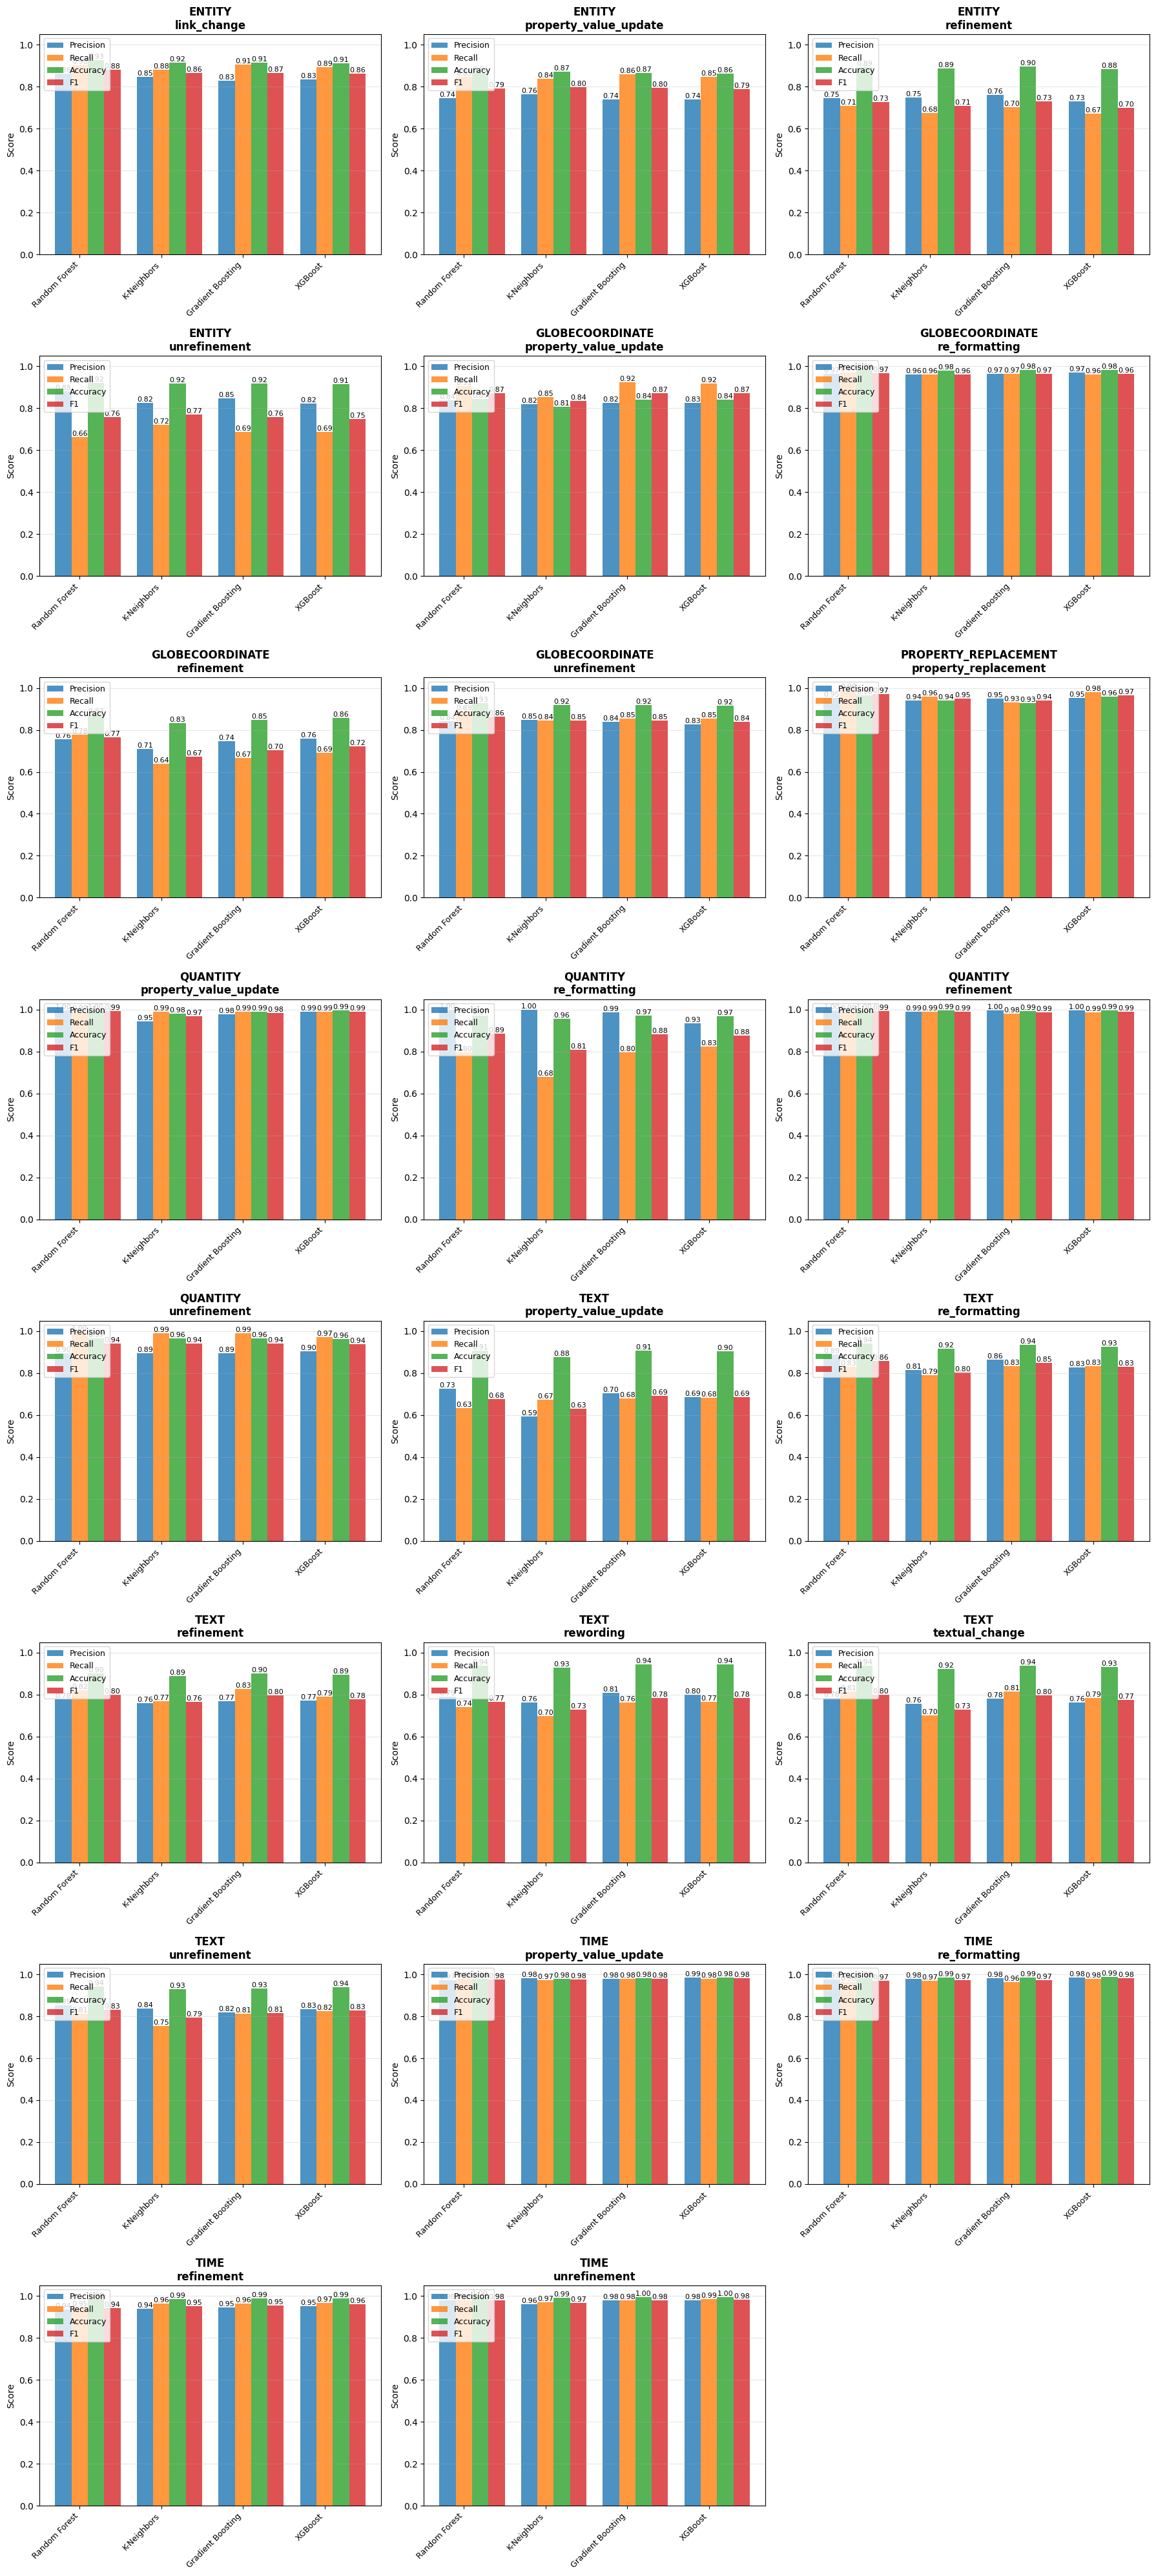

,datatype,label,best_model,best_f1,best_recall,best_precision
0,globecoordinate,property_value_update,random_forest,0.872211,0.924051,0.839844
1,globecoordinate,re_formatting,random_forest,0.967742,0.970149,0.969849
2,globecoordinate,refinement,random_forest,0.765766,0.776256,0.758794
3,globecoordinate,unrefinement,random_forest,0.864368,0.886792,0.848341
4,quantity,property_value_update,random_forest,0.993348,0.991150,0.995556
5,quantity,re_formatting,random_forest,0.886486,0.825243,1.000000
6,quantity,refinement,random_forest,0.992736,0.990338,0.995146
7,quantity,unrefinement,random_forest,0.942529,0.995146,0.904977
8,time,property_value_update,xgboost,0.982527,0.979893,0.985175
9,time,re_formatting,xgboost,0.980834,0.977528,0.984163


Overall best model (considering only F1 score):
Model: kn, Score: 2
Model: random_forest, Score: 14
Model: gradient_boosting, Score: 3
Model: xgboost, Score: 4
Overall best model is random_forest with score 14/ 23

Model Performance Summary (across all classification tasks):
            Model  Mean F1  Mean Precision  Mean Recall  Mean Accuracy
               kn     0.84            0.86         0.84           0.93
    random_forest     0.87            0.88         0.87           0.94
gradient_boosting     0.87            0.87         0.86           0.94
          xgboost     0.86            0.86         0.86           0.94


In [2]:

import pandas as pd

def plot_metrics(results_dt_label_model):
    models = ['random_forest', 'kn', 'gradient_boosting', 'xgboost']
    model_labels = ['Random Forest', 'K-Neighbors', 'Gradient Boosting', 'XGBoost']
    metrics = ['precision', 'recall', 'accuracy', 'f1']

    # Count subplots
    total_plots = sum(len(results_dt_label_model[dt]) for dt in results_dt_label_model)
    ncols = 3
    nrows = (total_plots + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(18, 5*nrows))
    if isinstance(axes, np.ndarray):
        axes = axes.flatten()
    else:
        axes = [axes]

    plot_idx = 0
    for datatype in sorted(results_dt_label_model.keys()):
        for label in sorted(results_dt_label_model[datatype].keys()):
            ax = axes[plot_idx]
            
            x = np.arange(len(models))
            width = 0.2
            
            for i, metric in enumerate(metrics):
                values = [results_dt_label_model[datatype][label][model][metric] for model in models] # metric (accuracy/precision/recall/f1) values for this label and datatype
                
                offset = (i - 1) * width
                bars = ax.bar(x + offset, values, width, label=metric.capitalize(), alpha=0.8)
                
                for bar in bars:
                    height = bar.get_height()
                    ax.text(bar.get_x() + bar.get_width()/2., height,
                        f'{height:.2f}',
                        ha='center', va='bottom', fontsize=8)
            
            ax.set_ylabel('Score')
            ax.set_title(f'{datatype.upper()}\n{label}', fontweight='bold', fontsize=12)
            ax.set_xticks(x)
            ax.set_xticklabels(model_labels, rotation=45, ha='right', fontsize=9)
            ax.legend(loc='upper left', fontsize=9)
            ax.grid(axis='y', alpha=0.3)
            ax.set_ylim([0, 1.05])
            
            plot_idx += 1

    for idx in range(plot_idx, len(axes)):
        axes[idx].set_visible(False)

    plt.tight_layout()
    plt.savefig('classifier_metrics_all.png', dpi=300, bbox_inches='tight')
    plt.show()

    # OVERALL: the best one seems to be gradient boosting, in some cases (not many) random forest does better


    score_per_model = {}
    df_data = {
        'datatype': [],
        'label': [],
        'best_model': [],
        'best_f1': [],
        'best_recall': [],
        'best_precision': []
    }
    for datatype in results_dt_label_model:
        for label in results_dt_label_model[datatype]:
            best_model = None
            best_f1 = 0
            best_recall = 0
            best_precision = 0
            for model in results_dt_label_model[datatype][label]:
                if model not in score_per_model:
                    score_per_model[model] = 0
                f1 = results_dt_label_model[datatype][label][model]['f1']
                recall = results_dt_label_model[datatype][label][model]['recall']
                precision = results_dt_label_model[datatype][label][model]['precision']
                if f1 > best_f1:
                    best_f1 = f1
                    best_model = model

                if recall > best_recall:
                    best_recall = recall
                
                if precision > best_precision:
                    best_precision = precision

            df_data['datatype'].append(datatype)
            df_data['label'].append(label)
            df_data['best_model'].append(best_model)
            df_data['best_f1'].append(best_f1)
            df_data['best_recall'].append(best_recall)
            df_data['best_precision'].append(best_precision)
            score_per_model[best_model] += 1

    df = pd.DataFrame(df_data)
    display(df)

    print('Overall best model (considering only F1 score):')

    best_score = 0
    best_model = None
    for model, score in score_per_model.items():
        if score > best_score:
            best_score = score
            best_model = model
        print(f'Model: {model}, Score: {score}')

    print(f'Overall best model is {best_model} with score {best_score}/ {sum(score_per_model.values())}')

    models = ['kn', 'random_forest', 'gradient_boosting', 'xgboost']

    model_averages = {model: {'f1': [], 'precision': [], 'recall': [], 'accuracy': []} 
                    for model in models}

    for datatype in results_dt_label_model:
        for label in results_dt_label_model[datatype]:
            for model in models:
                model_averages[model]['f1'].append(results_dt_label_model[datatype][label][model]['f1'])
                model_averages[model]['precision'].append(results_dt_label_model[datatype][label][model]['precision'])
                model_averages[model]['recall'].append(results_dt_label_model[datatype][label][model]['recall'])
                model_averages[model]['accuracy'].append(results_dt_label_model[datatype][label][model]['accuracy'])


    summary_stats = []
    for model in models:
        summary_stats.append({
            'Model': model,
            'Mean F1': np.mean(model_averages[model]['f1']).round(2),
            'Mean Precision': np.mean(model_averages[model]['precision']).round(2),
            'Mean Recall': np.mean(model_averages[model]['recall']).round(2),
            'Mean Accuracy': np.mean(model_averages[model]['accuracy']).round(2)
        })

    df_summary = pd.DataFrame(summary_stats)
    print("\nModel Performance Summary (across all classification tasks):")
    print(df_summary.to_string(index=False))


plot_metrics(results_dt_label_model_micro)

### Aggregate SHAP values across folds for each different label

In [148]:
import shap
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from sklearn.multioutput import MultiOutputClassifier
import pandas as pd

# each dot represents a SHAP value for a featura and an instance. the color indicates the feature value (high or low)
# you see how each feature importance varies across the dataset
# Features are ordered by importance from TOP to BOTTOM - the feature at the top is the most important

# Positive SHAP -> pushes prediction toward class 1 (positive)
# Negative SHAP -> pushes prediction toward class 0 (negative)

# Examples of how to read this plots:
# Feature at top, red dots on right side: "High values of this feature strongly predict positive class"
# Feature at top, blue dots on left side: "Low values of this feature strongly predict negative class"


def analyze_feature_importance_multilabel(classifiers, datatype, save_dir='feature_importance_analysis'):
    """
    Analyze feature importance across all folds for a given datatype.
    """
    import os
    os.makedirs(save_dir, exist_ok=True)
    
    df_type = pd.read_csv(f'src/classifiers/ml/features/gs_features_{datatype}.csv')
    with open(f'src/classifiers/ml/features/feature_cols_{datatype}.pkl', 'rb') as f:
        feature_cols = pickle.load(f)
    
    fold_results = classifiers[datatype]['results_folds']
    
    all_shap_values = defaultdict(list)  # {label_idx: [shap_arrays_from_each_fold]}
    all_X_test = []
    
    # Collect SHAP values from each fold
    for fold_idx, results_fold in enumerate(fold_results):
        
        model = results_fold['model']
            
        test_index = results_fold['test_index']
        label_binarizer = results_fold['multi_label_binarizer']
        X_test = results_fold['X_test']
        
        # Get test data for this fold
        # df_test = df_type.loc[test_index].copy()
        # X_test = df_test[feature_cols].copy()
        
        if isinstance(model, MultiOutputClassifier):
            # For MultiOutputClassifier, compute SHAP for each estimator
            shap_values_list = []
            for estimator in model.estimators_:  # one esxtimator per label
                explainer = shap.TreeExplainer(estimator)
                shap_vals = explainer.shap_values(X_test)

                if isinstance(shap_vals, list):
                    shap_vals = shap_vals[1]  # positive class
                shap_values_list.append(shap_vals)

            shap_values = np.stack(shap_values_list, axis=-1)

        else:
            # Compute SHAP values
            explainer = shap.TreeExplainer(model)
            shap_values_raw = explainer.shap_values(X_test)

            if isinstance(shap_values_raw, list):
                shap_values = np.stack(shap_values_raw, axis=-1)
            else:
                shap_values = shap_values_raw
        
        # Store SHAP values for each label (positive class only)
        n_labels = len(label_binarizer.classes_)
        if isinstance(model, MultiOutputClassifier):
            # MultiOutputClassifier: already computed positive class only for each label
            # Shape: (n_samples, n_features, n_labels)
            for label_idx in range(n_labels):
                if 'non' not in label_binarizer.classes_[label_idx]:
                    shap_for_label = shap_values[:, :, label_idx]
                    all_shap_values[label_idx].append(shap_for_label)
        else:
            # Multi-class single output: need to extract positive class for each label
            # Shape: (n_samples, n_features, n_classes_total)
            if datatype == 'reverted_edit' or datatype == 'property_replacement':
                # Binary classification: only 2 classes total
                if shap_values.shape[2] == 2:
                    shap_for_label = shap_values[:, :, 1]  # positive class
                    all_shap_values[1].append(shap_for_label)
            else:
                # Multi-label binarized: pairs of (negative, positive) for each label
                for label_idx in range(n_labels):
                    if 'non' not in label_binarizer.classes_[label_idx]:
                        # Each label has 2 classes: idx*2 (negative) and idx*2+1 (positive)
                        shap_for_label = shap_values[:, :, label_idx * 2 + 1]
                        all_shap_values[label_idx].append(shap_for_label)
        # Store test data
        all_X_test.append(pd.DataFrame(X_test, columns=feature_cols))
    
    # Concatenate all test data
    X_test_combined = pd.concat(all_X_test, axis=0)
    
    label_names = fold_results[0]['multi_label_binarizer'].classes_
    
    # Create aggregated plots for each label
    for label_idx, label_name in enumerate(label_names):
        
        # puts the shap values from each fold as a new row, stacks them vertically

        if 'non' in label_name:
            continue
        shap_combined = np.vstack(all_shap_values[label_idx])
        
        # Create summary plot
        plt.figure(figsize=(10, 8))
        shap.summary_plot(
            shap_combined, 
            X_test_combined,
            feature_names=feature_cols,
            show=False
        )
        plt.title(f'Feature Importance - {datatype} - {label_name}', fontsize=14, pad=20)
        plt.tight_layout()
        plt.savefig(f'{save_dir}/{datatype}_{label_name}_summary.png', dpi=300, bbox_inches='tight')
        plt.close()
    
    # Calculate average feature importance across all labels and folds
    feature_importance_summary = calculate_overall_importance(
        datatype,
        all_shap_values, feature_cols, label_names
    )
    
    # Save summary
    feature_importance_summary.to_csv(
        f'{save_dir}/{datatype}_feature_importance_summary.csv', 
        index=False
    )
    
    return feature_importance_summary, X_test_combined, all_shap_values


def calculate_overall_importance(datatype, all_shap_values, feature_cols, label_names):
    """
    Calculate mean absolute SHAP values for each feature across all labels and folds.
    """
    importance_data = []
    
    for label_idx, label_name in enumerate(label_names):
        # Concatenate SHAP values for this label across folds
        if 'non' in label_name:
            continue
        shap_combined = np.vstack(all_shap_values[label_idx])
        
        # Calculate mean absolute SHAP value for each feature across all folds
        mean_abs_shap = np.abs(shap_combined).mean(axis=0)
        
        for feat_idx, feat_name in enumerate(feature_cols):
            importance_data.append({
                'label': label_name,
                'feature': feat_name,
                'mean_abs_shap': mean_abs_shap[feat_idx]
            })
    
    df_importance = pd.DataFrame(importance_data)
    
    # Also calculate overall importance (averaged across all labels and folds)
    overall_importance = df_importance.groupby('feature')['mean_abs_shap'].mean().reset_index()
    overall_importance = overall_importance.sort_values('mean_abs_shap', ascending=False)
    overall_importance['label'] = 'OVERALL'
    
    # Combine
    df_final = pd.concat([df_importance, overall_importance], ignore_index=True)
    
    return df_final



In [150]:
with open('src/classifiers/ml/training_info/training_info_random_forest.pkl', 'rb') as f:
    classifiers = pickle.load(f)

datatypes = ['entity', 'text', 'time', 'globecoordinate', 'quantity']

print(classifiers.keys())

# datatypes = ['entity', 'text']
for datatype in datatypes: 
    print(f"\n{'='*60}")
    print(f"Analyzing {datatype}")
    print(f"{'='*60}")
     
    importance_summary, X_test, shap_values = analyze_feature_importance_multilabel(
        classifiers, 
        datatype,
        save_dir=f'feature_importance_analysis/{datatype}'
    )
    
    
    print(f"\nTop 10 features for {datatype} (averaged across all labels):")
    overall = importance_summary[importance_summary['label'] == 'OVERALL']
    print(overall.to_string(index=False))

dict_keys(['globecoordinate', 'quantity', 'time', 'text', 'entity', 'property_replacement'])

Analyzing entity

Top 10 features for entity (averaged across all labels):
  label                        feature  mean_abs_shap
OVERALL                     new_in_old       0.022258
OVERALL   old_value_subclass_new_value       0.013460
OVERALL                  token_overlap       0.008528
OVERALL           complete_replacement       0.007223
OVERALL old_value_located_in_new_value       0.006147
OVERALL        label_cosine_similarity       0.005900
OVERALL   new_value_subclass_old_value       0.005575
OVERALL                length_diff_abs       0.005428
OVERALL           levenshtein_distance       0.004789
OVERALL                     old_in_new       0.004361
OVERALL            edit_distance_ratio       0.003453
OVERALL  description_cosine_similarity       0.003381
OVERALL                token_count_old       0.003361
OVERALL           structure_similarity       0.002591
OVERALL              

## Analyze results

In [120]:
with open('src/classifiers/ml/training_info/training_info_random_forest.pkl', 'rb') as f:
    training_info_rf = pickle.load(f)

datatype = 'text'
results_folds = training_info_rf[datatype]['results_folds']

results_fold_0 = results_folds[0]
# for result_f in results_folds:
model = results_fold_0['classifier']
multi_label_binarizer = results_fold_0['multi_label_binarizer']
y_pred = results_fold_0['y_pred']
y_test = results_fold_0['y_test']
test_index = results_fold_0['test_index']
model_obj = results_fold_0['model']

y_pred_labels = multi_label_binarizer.inverse_transform(y_pred) # transform back to original labels
y_test_labels = multi_label_binarizer.inverse_transform(y_test)


pred_df = pd.DataFrame({
    'predicted_labels': [', '.join(labels) if labels else '(none)' for labels in y_pred_labels],
    'true_labels': [', '.join(labels) if labels else '(none)' for labels in y_test_labels]
}, index=test_index)

with open(f'src/classifiers/ml/features/feature_cols_{datatype}.pkl', 'rb') as f:
    feature_cols = pickle.load(f)

df_type = pd.read_csv(f'src/classifiers/ml/features/gs_features_{datatype}.csv', index_col=0)
print("Test index first 10:", test_index[:10])
print("Df_type index:", df_type.index[:10])
df_with_predictions = df_type.loc[test_index].copy()

df_type['original_index'] = df_type.index
df_with_predictions = df_with_predictions.join(pred_df)

# Get features and scale
X = df_with_predictions[feature_cols]

with open('src/classifiers/ml/features/scalers.pkl', 'rb') as f:
    scalers = pickle.load(f)

X_scaled = scalers[datatype].transform(X)

labels = multi_label_binarizer.classes_
n_samples = X_scaled.shape[0]
all_proba = model_obj.predict_proba(X_scaled)

results_list = []
for i in range(n_samples):
    # Get true label
    true_label_str = df_with_predictions.iloc[i]['label']
    predicted_label_str = df_with_predictions.iloc[i]['predicted_labels']
    
    # Create row dictionary
    row_data = {
        'index': df_with_predictions.index[i],
        'true_label': true_label_str,
        'predicted_label': predicted_label_str,
    }
    
    # Add probability for positive class for each label
    if isinstance(all_proba, list):
        # Multi-output classifier (Random Forest, Gradient Boosting)
        for label_idx, label in enumerate(multi_label_binarizer.classes_):
            prob_positive = all_proba[label_idx][i, 1]  # Positive class probability
            row_data[f'prob_{label}'] = prob_positive
    results_list.append(row_data)

results_df = pd.DataFrame(results_list)


results_df['true_labels_list'] = results_df['true_label'].fillna('').str.split(',').apply(lambda x: [l.strip() for l in x if l.strip()])
results_df['predicted_labels_list'] = results_df['predicted_label'].apply(lambda x: [] if x == '(none)' else [l.strip() for l in x.split(',') if l.strip()])

# Transform to binary using the EXISTING multi_label_binarizer (don't fit again!)
true_labels_binary = multi_label_binarizer.transform(results_df['true_labels_list'])
predicted_labels_binary = multi_label_binarizer.transform(results_df['predicted_labels_list'])

# Create DataFrames with proper column names
true_labels_df = pd.DataFrame(
    true_labels_binary, 
    columns=[f'true_{label}' for label in multi_label_binarizer.classes_],
    index=results_df.index
)

predicted_labels_df = pd.DataFrame(
    predicted_labels_binary, 
    columns=[f'pred_{label}' for label in multi_label_binarizer.classes_],
    index=results_df.index
)

results_df = results_df.join(true_labels_df).join(predicted_labels_df)

display(results_df[['true_label', 'predicted_label', 'true_property_value_update',
       'true_re_formatting', 'true_refinement', 'true_rewording',
       'true_textual_change', 'true_unrefinement',
       'pred_property_value_update', 'pred_re_formatting', 'pred_refinement',
       'pred_rewording', 'pred_textual_change', 'pred_unrefinement']].head(10))

for label in labels:
    true_positives = results_df[(results_df[f'true_{label}'] == 1) & (results_df[f'pred_{label}'] == 1)].shape[0]
    false_positives = results_df[(results_df[f'true_{label}'] != 1) & (results_df[f'pred_{label}'] == 1)].shape[0]
    false_negatives = results_df[(results_df[f'true_{label}'] == 1) & (results_df[f'pred_{label}'] != 1)].shape[0]
    true_negatives = results_df[(results_df[f'true_{label}'] != 1) & (results_df[f'pred_{label}'] != 1)].shape[0]

    precision = true_positives / (true_positives + false_positives) 
    recall = true_positives / (true_positives + false_negatives)
    f1 = 2 * ((precision * recall)/(precision + recall))

    print(f'-- Metrics for label {label} --')
    print('Precision: ', precision)
    print('Precision in fold: ', results_fold_0['metrics_results'][label]['precision'])
    print('Recall: ', recall)
    print('Recall in fold: ', results_fold_0['metrics_results'][label]['recall'])
    print('F1: ', f1)
    print('F1 in fold: ', results_fold_0['metrics_results'][label]['f1'])


Test index first 10: [  9  52  61  69  74  76  81  89 122 124]
Df_type index: Index([1, 3, 4, 5, 9, 10, 11, 12, 21, 28], dtype='int64')


,true_label,predicted_label,true_property_value_update,true_re_formatting,true_refinement,true_rewording,true_textual_change,true_unrefinement,pred_property_value_update,pred_re_formatting,pred_refinement,pred_rewording,pred_textual_change,pred_unrefinement
0,property_value_update,property_value_update,1,0,0,0,0,0,1,0,0,0,0,0
1,unrefinement,property_value_update,0,0,0,0,0,1,1,0,0,0,0,0
2,property_value_update,refinement,1,0,0,0,0,0,0,0,1,0,0,0
3,property_value_update,refinement,1,0,0,0,0,0,0,0,1,0,0,0
4,refinement,refinement,0,0,1,0,0,0,0,0,1,0,0,0
5,re_formatting,re_formatting,0,1,0,0,0,0,0,1,0,0,0,0
6,re_formatting,re_formatting,0,1,0,0,0,0,0,1,0,0,0,0
7,"refinement, rewording","refinement, rewording",0,0,1,1,0,0,0,0,1,1,0,0
8,re_formatting,re_formatting,0,1,0,0,0,0,0,1,0,0,0,0
9,re_formatting,re_formatting,0,1,0,0,0,0,0,1,0,0,0,0


-- Metrics for label property_value_update --
Precision:  0.7878787878787878
Precision in fold:  0.7878787878787878
Recall:  0.65
Recall in fold:  0.65
F1:  0.7123287671232875
F1 in fold:  0.7123287671232876
-- Metrics for label re_formatting --
Precision:  0.8793103448275862
Precision in fold:  0.8793103448275862
Recall:  0.864406779661017
Recall in fold:  0.864406779661017
F1:  0.8717948717948718
F1 in fold:  0.8717948717948718
-- Metrics for label refinement --
Precision:  0.7571428571428571
Precision in fold:  0.7571428571428571
Recall:  0.8688524590163934
Recall in fold:  0.8688524590163934
F1:  0.8091603053435115
F1 in fold:  0.8091603053435115
-- Metrics for label rewording --
Precision:  0.9411764705882353
Precision in fold:  0.9411764705882353
Recall:  0.64
Recall in fold:  0.64
F1:  0.7619047619047621
F1 in fold:  0.7619047619047619
-- Metrics for label textual_change --
Precision:  0.8095238095238095
Precision in fold:  0.8095238095238095
Recall:  0.8095238095238095
Recall i

In [ ]:
# Check the actual prediction probabilities for the (none) cases
model_obj = results_fold_0['model']

# Get indices of (none) predictions in the test set
none_indices = [i for i, labels in enumerate(y_pred_labels) if len(labels) == 0]

print(f"Number of (none) predictions: {len(none_indices)}")
print(f"First few (none) indices in test set: {none_indices[:10]}")
X_test = results_fold_0['X_test']
# Get the prediction probabilities for these cases
if hasattr(model_obj, 'predict_proba'):
    X_test_none = X_test[none_indices[:5]]  # First 5 (none) cases
    proba = model_obj.predict_proba(X_test_none)
    
    print("\nPrediction probabilities for first (none) case:")
    print("Classes:", multi_label_binarizer.classes_)
    print("Probabilities:", proba[0])
    # For each example you get a list of lists with prob of negative, positive for each label

In [ ]:
# test_index does train/test split mapping  
# test_index[0] = 5 -> position 0 in test set corresponds to row 5 in original df
# this is because of the k fold split during training

# get the none prediction indices (positions in test set)
none_indices = [i for i, labels in enumerate(y_pred_labels) if len(labels) == 0]
print(f"None indices (test set positions): {none_indices[:10]}")

# get the actual dataframe indices for these cases
none_df_indices = test_index[none_indices]
print(f"None indices (original df indices): {none_df_indices[:10]}")

df_type = pd.read_csv(f'src/classifiers/ml/features/gs_features_{datatype}.csv', index_col=0)

# get the actual rows using original indices of the df
none_cases = df_type.loc[none_df_indices].copy()

# Add prediction info
none_cases['true_labels'] = [', '.join(y_test_labels[i]) for i in none_indices]
none_cases['predicted_labels'] = '(none)'

all_test_probs = {}
for label_idx, label in enumerate(multi_label_binarizer.classes_):
    if isinstance(model_obj.predict_proba(X_test), list):
        # sklearn 
        all_test_probs[label] = model_obj.predict_proba(X_test)[label_idx][:, 1]
    else:
        # xgboost
        all_test_probs[label] = model_obj.predict_proba(X_test)[:, label_idx]

for label in multi_label_binarizer.classes_:
    none_cases[f'prob_{label}'] = [all_test_probs[label][i] for i in none_indices] 
    # here I use non_indices because im indexing the result on X_test

display_cols = ['old_value', 'new_value', 
                'true_labels', 'predicted_labels'] + \
               [f'prob_{label}' for label in multi_label_binarizer.classes_]

print(f"Total (none) predictions: {len(none_cases)}")
display(none_cases[display_cols])


# Results for best classifier (Gradient Boosting)

In [167]:
results_dt_label_model = results_dt_label_model_micro

for datatype in results_dt_label_model:
    for label in results_dt_label_model[datatype]:
        best_model = None
        best_f1 = 0
        best_recall = 0
        best_precision = 0
        for model in results_dt_label_model[datatype][label]:
            if model == 'gradient_boosting':
                print(f'{datatype} - {label}: {round(results_dt_label_model[datatype][label][model]['precision'], 2)} & {round(results_dt_label_model[datatype][label][model]['recall'], 2)} & {round(results_dt_label_model[datatype][label][model]['f1'], 2)} & {round(results_dt_label_model[datatype][label][model]['accuracy'], 2)} ')
                

globecoordinate - property_value_update: 0.83 & 0.93 & 0.88 & 0.85 
globecoordinate - re_formatting: 0.97 & 0.98 & 0.97 & 0.99 
globecoordinate - refinement: 0.76 & 0.68 & 0.72 & 0.86 
globecoordinate - unrefinement: 0.84 & 0.83 & 0.84 & 0.92 
quantity - property_value_update: 0.99 & 1.0 & 0.99 & 0.99 
quantity - re_formatting: 0.96 & 0.8 & 0.87 & 0.97 
quantity - refinement: 0.99 & 0.98 & 0.98 & 0.99 
quantity - unrefinement: 0.89 & 1.0 & 0.94 & 0.96 
time - property_value_update: 0.91 & 0.9 & 0.91 & 0.91 
time - re_formatting: 0.91 & 0.93 & 0.92 & 0.96 
time - refinement: 0.93 & 0.91 & 0.92 & 0.98 
time - unrefinement: 0.69 & 0.71 & 0.7 & 0.92 
text - property_value_update: 0.72 & 0.7 & 0.71 & 0.91 
text - re_formatting: 0.83 & 0.84 & 0.83 & 0.92 
text - refinement: 0.78 & 0.84 & 0.81 & 0.91 
text - rewording: 0.87 & 0.73 & 0.79 & 0.96 
text - textual_change: 0.76 & 0.79 & 0.77 & 0.92 
text - unrefinement: 0.85 & 0.82 & 0.84 & 0.94 
entity - link_change: 0.83 & 0.91 & 0.87 & 0.92 
en

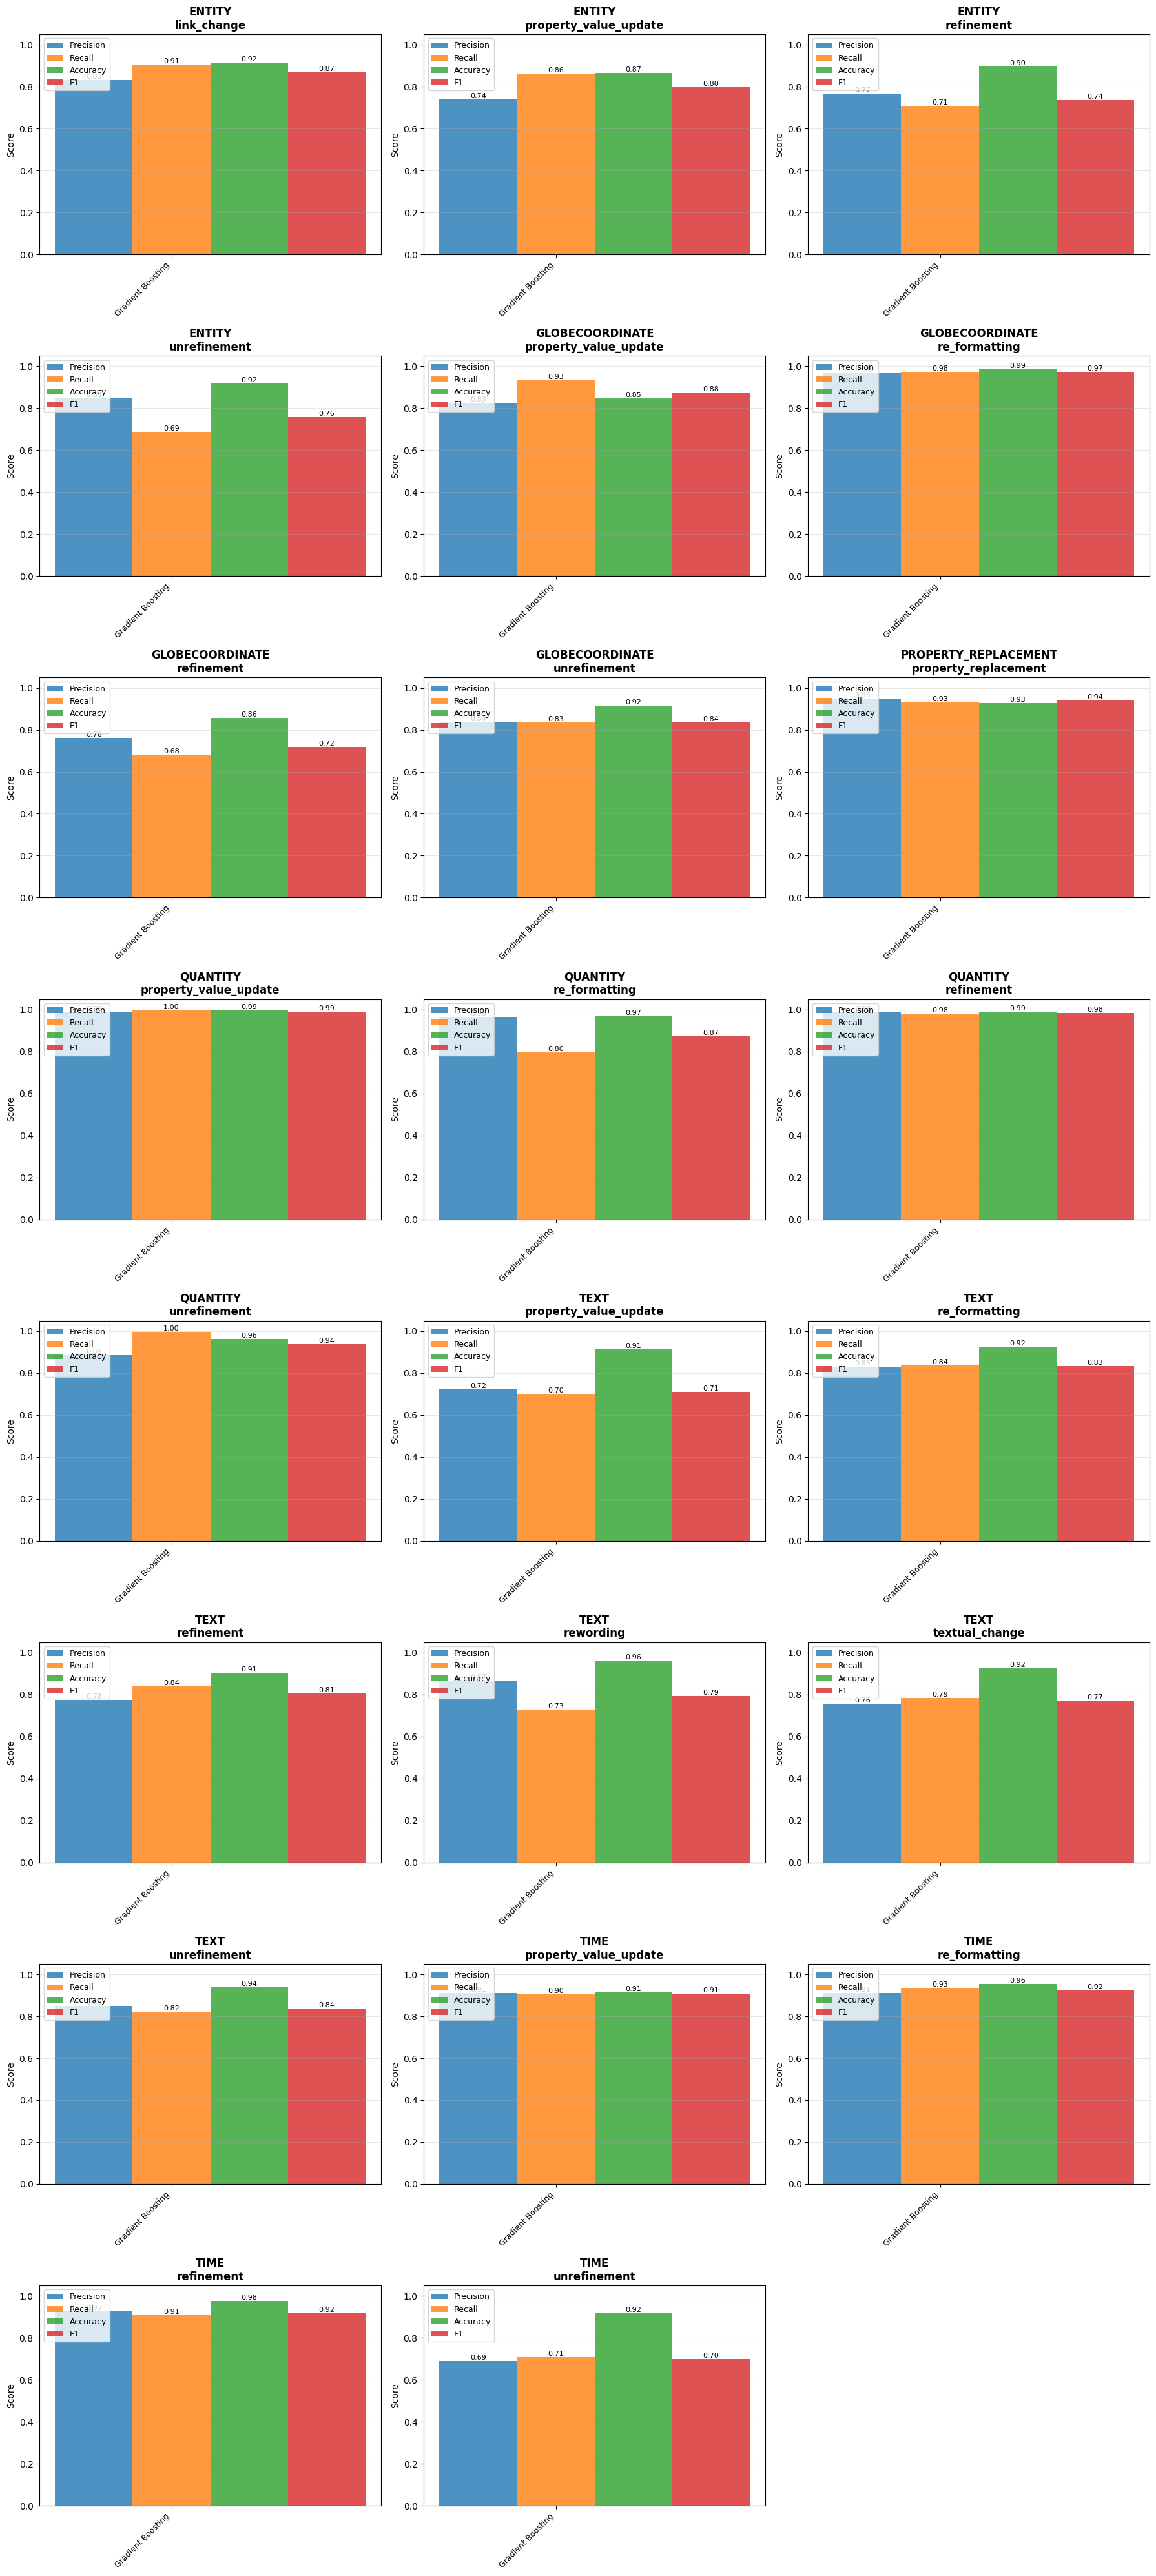

,datatype,label,best_model,best_f1,best_recall,best_precision
0,globecoordinate,property_value_update,gradient_boosting,0.876115,0.932489,0.835907
1,globecoordinate,re_formatting,gradient_boosting,0.972705,0.975124,0.970297
2,globecoordinate,refinement,random_forest,0.762332,0.776256,0.760204
3,globecoordinate,unrefinement,random_forest,0.868966,0.891509,0.848341
4,quantity,property_value_update,kn,0.995556,0.995556,0.995556
5,quantity,re_formatting,kn,0.886486,0.815534,1.000000
6,quantity,refinement,kn,0.990385,0.985646,1.000000
7,quantity,unrefinement,gradient_boosting,0.937931,0.995122,0.892377
8,time,property_value_update,gradient_boosting,0.906612,0.908967,0.913103
9,time,re_formatting,xgboost,0.924731,0.940919,0.910448


Overall best model (considering only F1 score):
Model: kn, Score: 6
Model: random_forest, Score: 7
Model: gradient_boosting, Score: 8
Model: xgboost, Score: 2
Overall best model is gradient_boosting with score 8/ 23

Model Performance Summary (across all 24 classification tasks):
            Model  Mean Precision  Mean Recall  Mean F1  Mean Accuracy
               kn            0.83         0.82     0.82           0.92
    random_forest            0.85         0.84     0.84           0.93
gradient_boosting            0.85         0.85     0.85           0.93
          xgboost            0.84         0.84     0.84           0.93


In [168]:

import pandas as pd

def plot_metrics(results_dt_label_model):
    models = ['gradient_boosting']
    model_labels = ['Gradient Boosting']
    metrics = ['precision', 'recall', 'accuracy', 'f1']

    # Count subplots
    total_plots = sum(len(results_dt_label_model[dt]) for dt in results_dt_label_model)
    ncols = 3
    nrows = (total_plots + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(18, 5*nrows))
    if isinstance(axes, np.ndarray):
        axes = axes.flatten()
    else:
        axes = [axes]

    plot_idx = 0
    for datatype in sorted(results_dt_label_model.keys()):
        for label in sorted(results_dt_label_model[datatype].keys()):
            ax = axes[plot_idx]
            
            x = np.arange(len(models))
            width = 0.2
            
            for i, metric in enumerate(metrics):
                values = [results_dt_label_model[datatype][label][model][metric] for model in models] # metric (accuracy/precision/recall/f1) values for this label and datatype
                
                offset = (i - 1) * width
                bars = ax.bar(x + offset, values, width, label=metric.capitalize(), alpha=0.8)
                
                for bar in bars:
                    height = bar.get_height()
                    ax.text(bar.get_x() + bar.get_width()/2., height,
                        f'{height:.2f}',
                        ha='center', va='bottom', fontsize=8)
            
            ax.set_ylabel('Score')
            ax.set_title(f'{datatype.upper()}\n{label}', fontweight='bold', fontsize=12)
            ax.set_xticks(x)
            ax.set_xticklabels(model_labels, rotation=45, ha='right', fontsize=9)
            ax.legend(loc='upper left', fontsize=9)
            ax.grid(axis='y', alpha=0.3)
            ax.set_ylim([0, 1.05])
            
            plot_idx += 1

    for idx in range(plot_idx, len(axes)):
        axes[idx].set_visible(False)

    plt.tight_layout()
    plt.savefig('classifier_metrics_all.png', dpi=300, bbox_inches='tight')
    plt.show()

    # OVERALL: the best one seems to be gradient boosting, in some cases (not many) random forest does better


    score_per_model = {}
    df_data = {
        'datatype': [],
        'label': [],
        'best_model': [],
        'best_f1': [],
        'best_recall': [],
        'best_precision': []
    }
    for datatype in results_dt_label_model:
        for label in results_dt_label_model[datatype]:
            best_model = None
            best_f1 = 0
            best_recall = 0
            best_precision = 0
            for model in results_dt_label_model[datatype][label]:
                if model not in score_per_model:
                    score_per_model[model] = 0
                f1 = results_dt_label_model[datatype][label][model]['f1']
                recall = results_dt_label_model[datatype][label][model]['recall']
                precision = results_dt_label_model[datatype][label][model]['precision']
                if f1 > best_f1:
                    best_f1 = f1
                    best_model = model

                if recall > best_recall:
                    best_recall = recall
                
                if precision > best_precision:
                    best_precision = precision

            df_data['datatype'].append(datatype)
            df_data['label'].append(label)
            df_data['best_model'].append(best_model)
            df_data['best_f1'].append(best_f1)
            df_data['best_recall'].append(best_recall)
            df_data['best_precision'].append(best_precision)
            score_per_model[best_model] += 1

    df = pd.DataFrame(df_data)
    display(df)

    print('Overall best model (considering only F1 score):')

    best_score = 0
    best_model = None
    for model, score in score_per_model.items():
        if score > best_score:
            best_score = score
            best_model = model
        print(f'Model: {model}, Score: {score}')

    print(f'Overall best model is {best_model} with score {best_score}/ {sum(score_per_model.values())}')

    models = ['kn', 'random_forest', 'gradient_boosting', 'xgboost']

    model_averages = {model: {'f1': [], 'precision': [], 'recall': [], 'accuracy': []} 
                    for model in models}

    for datatype in results_dt_label_model:
        for label in results_dt_label_model[datatype]:
            for model in models:
                model_averages[model]['f1'].append(results_dt_label_model[datatype][label][model]['f1'])
                model_averages[model]['precision'].append(results_dt_label_model[datatype][label][model]['precision'])
                model_averages[model]['recall'].append(results_dt_label_model[datatype][label][model]['recall'])
                model_averages[model]['accuracy'].append(results_dt_label_model[datatype][label][model]['accuracy'])


    summary_stats = []
    for model in models:
        summary_stats.append({
            'Model': model,
            'Mean Precision': np.mean(model_averages[model]['precision']).round(2),
            'Mean Recall': np.mean(model_averages[model]['recall']).round(2),
            'Mean F1': np.mean(model_averages[model]['f1']).round(2),
            'Mean Accuracy': np.mean(model_averages[model]['accuracy']).round(2)
        })

    df_summary = pd.DataFrame(summary_stats)
    print("\nModel Performance Summary (across all 24 classification tasks):")
    print(df_summary.to_string(index=False))


plot_metrics(results_dt_label_model_micro)

## Features per datatype/classification task

In [ ]:
import pickle

datatypes = ['text', 'entity', 'quantity', 'time', 'globecoordinate', 'property_replacement']

for datatype in datatypes:
    with open(f'src/classifiers/ml/features/feature_cols_{datatype}.pkl', 'rb') as f:
        feature_cols = pickle.load(f)
        print(f' --------- {datatype} ------------- ')
        for feature in feature_cols:
            print(feature)

In [177]:
TRAINING_RESULTS = 'src/results/training'

with open(f'{TRAINING_RESULTS}/best_model_training_info.pkl', 'rb') as f:
    training_info_model = pickle.load(f)

dt_label = 'quantity'
results_folds = training_info_model[dt_label]['results_folds']

X_new = np.random.randn(3, 10)  # 3 new instances, 10 features
print(f"\nNew data shape: {X_new.shape}")
print(X_new)

all_predictions = []

for i, fold_result in enumerate(results_folds):
    model = fold_result['model']
    
    # Get probability predictions for each class
    # For multi-label, this returns shape (n_samples, n_classes)
    pred_proba = model.predict_proba(X_new)
    
    # predict_proba for multi-label returns list of arrays (one per class)
    # Each element is (n_samples, 2) for [prob_class_0, prob_class_1]
    # want (n_samples, n_classes) with prob of class being 1
    
    if isinstance(pred_proba, list):  # Multi-label case
        # positive class (index 1) for each label
        # each p is an array of lists, corresponding to a specific label
        # when we do p[:, 1] we are getting the prob of class 1 for all examples, for that label
        # with np.column_stack, we stack them on a column, so we get:
        # e.g. pred_proba = array([[0.99799539, 0.00200461], [0.99799539, 0.00200461],[0.00441102, 0.99558898]]), array([[0.99322399, 0.00677601],[0.99606133, 0.00393867],[0.01199732, 0.98800268]])
        # p = array([[0.99799539, 0.00200461], [0.99799539, 0.00200461],[0.00441102, 0.99558898]])
        # p[:, 1] = [ 0.00200461
        #             0.00200461
        #             0.99558898 ]
        # for the next label, it will be another column
        pred_proba_positive = np.column_stack([p[:, 1] for p in pred_proba]) 
    else:  # Single-label case
        pred_proba_positive = pred_proba
    
    # has one array for each fold
    all_predictions.append(pred_proba_positive)

# Stack all predictions: shape (n_folds, n_samples, n_classes)
all_predictions = np.array(all_predictions)

# Average across folds: shape (n_samples, n_classes)
avg_prediction = np.mean(all_predictions, axis=0)

# Apply 0.5 threshold for each instance
final_labels = (avg_prediction >= 0.5).astype(int)

# Apply fallback for instances with no labels
for i in range(len(final_labels)):
    if not final_labels[i].any():  # No label assigned
        highest_idx = np.argmax(avg_prediction[i])
        final_labels[i, highest_idx] = 1

# get label binarizer to create column of labels
multi_label_binarizer = results_folds[0]['multi_label_binarizer'] # it's the same for all folds

final_labels_transformed = multi_label_binarizer.inverse_transform(final_labels)

pred_df = pd.DataFrame({
    'predicted_labels': [', '.join(labels) if labels else '(none)' for labels in final_labels_transformed]
}, index=X_index)

results_df = X_new.join(predicted_labels_df)





New data shape: (3, 10)
[[-0.28824404 -1.03522662 -1.49555486 -0.19794768  1.01347035  2.51517494
  -0.08888981  0.32170273  0.62549807  1.61255218]
 [ 0.07887003 -0.15827797 -1.07065278  0.34289219 -0.35790893 -1.18934737
   0.14796184  0.42015466  0.43830673 -1.71050769]
 [-0.07174657 -1.343553   -0.64783239  0.87982788 -0.31322877  1.74113828
   0.34474271 -1.91862182 -1.0316351   0.42849096]]
Initial pred_proba
[array([[0.99799539, 0.00200461],
       [0.99799539, 0.00200461],
       [0.99799539, 0.00200461]]), array([[0.99765478, 0.00234522],
       [0.99660271, 0.00339729],
       [0.77130023, 0.22869977]]), array([[0.72070409, 0.27929591],
       [0.99681033, 0.00318967],
       [0.99502984, 0.00497016]]), array([[0.80389951, 0.19610049],
       [0.98077381, 0.01922619],
       [0.96290049, 0.03709951]])]
Initial pred_proba
[array([[0.99799208, 0.00200792],
       [0.99799208, 0.00200792],
       [0.99799208, 0.00200792]]), array([[0.99763751, 0.00236249],
       [0.99683861, 0

In [1]:
import pickle
with open(f'src/classifiers/ml/features/feature_cols_text.pkl', 'rb') as f:
    feature_cols = pickle.load(f)

print(feature_cols)


['length_diff_abs', 'token_count_old', 'token_count_new', 'token_overlap', 'old_in_new', 'new_in_old', 'levenshtein_distance', 'edit_distance_ratio', 'complete_replacement', 'structure_similarity', 'char_insertions', 'char_deletions', 'avg_word_similarity', 'has_significant_prefix', 'has_significant_suffix', 'full_cosine_similarity']


### Shapley values for odd cases

scaler expects: ['length_diff_abs', 'token_count_old', 'token_count_new', 'token_overlap', 'old_in_new', 'new_in_old', 'levenshtein_distance', 'edit_distance_ratio', 'complete_replacement', 'structure_similarity', 'label_cosine_similarity', 'description_cosine_similarity', 'full_cosine_similarity', 'new_value_part_of_old_value', 'old_value_part_of_new_value', 'new_value_subclass_old_value', 'old_value_subclass_new_value', 'new_value_has_parts_old_value', 'old_value_has_parts_new_value', 'new_value_located_in_old_value', 'old_value_located_in_new_value']
your cols: ['length_diff_abs', 'token_count_old', 'token_count_new', 'token_overlap', 'old_in_new', 'new_in_old', 'levenshtein_distance', 'edit_distance_ratio', 'complete_replacement', 'structure_similarity', 'label_cosine_similarity', 'description_cosine_similarity', 'full_cosine_similarity', 'old_value_subclass_new_value', 'new_value_subclass_old_value', 'old_value_located_in_new_value', 'new_value_located_in_old_value', 'old_value_ha

['link_change' 'property_value_update' 'refinement' 'unrefinement']


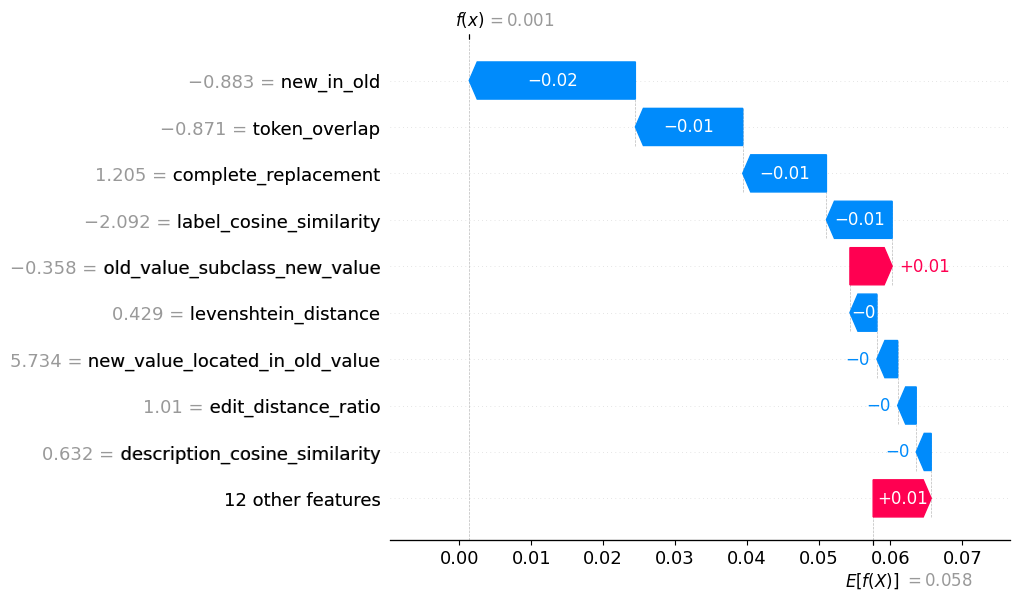

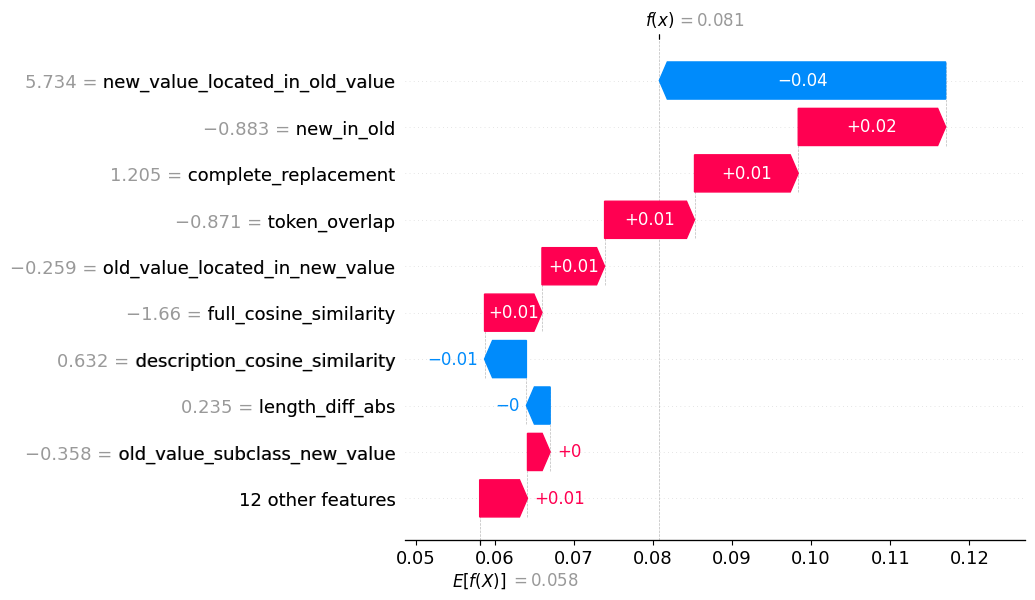

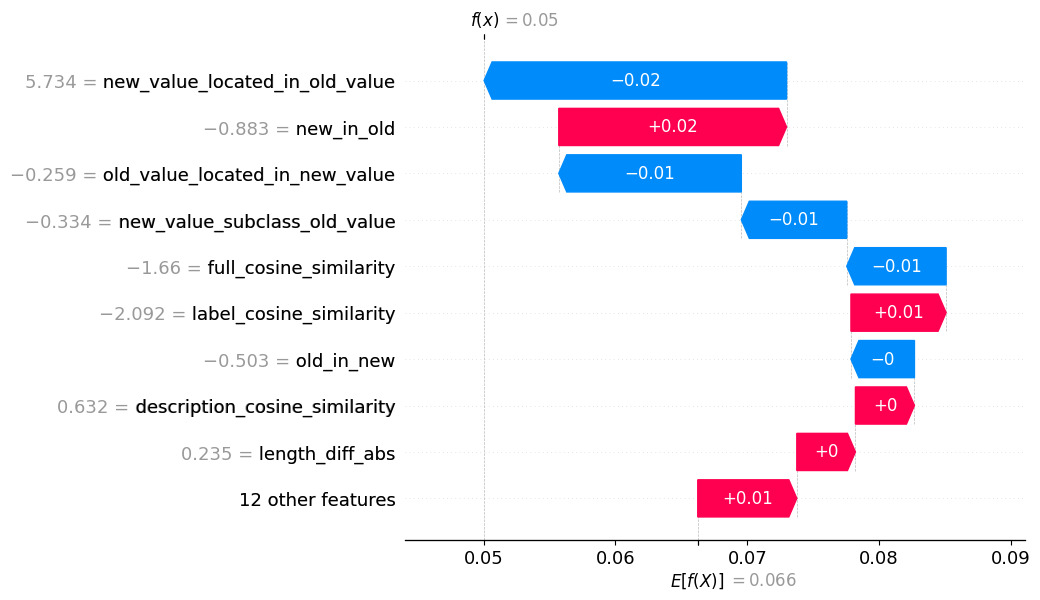

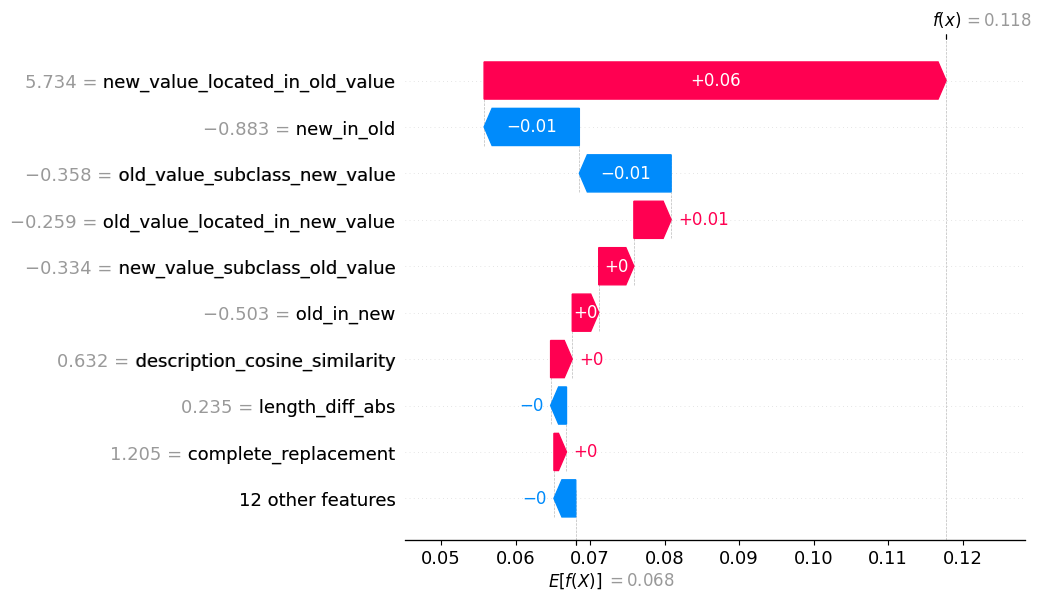

In [3]:
import shap
import pandas as pd
import pickle

feature_cols = pickle.load(open(f'src/classifiers/ml/features/feature_cols_entity.pkl', 'rb'))

X_test = pd.read_csv(f'odd_cases_unref.csv', usecols=feature_cols)


with open(f'src/classifiers/ml/features/scalers.pkl', 'rb') as f:
    scalers = pickle.load(f)

expected_cols = scalers['entity'].feature_names_in_.tolist()
print("scaler expects:", expected_cols)
print("your cols:", X_test.columns.tolist())

# reorder to match scaler
X_test = X_test[expected_cols]

X_scaled = scalers['entity'].transform(X_test)

print(f"Scaled data shape: {X_scaled.shape}")

with open(f'src/results/training/best_model_training_info.pkl', 'rb') as f:
    training_info_model = pickle.load(f)

model = training_info_model['entity']['results_folds'][0]['model']
multi_label_binarizer = training_info_model['entity']['results_folds'][0]['multi_label_binarizer']
print(multi_label_binarizer.classes_)
X_scaled_df = pd.DataFrame(X_scaled, columns=X_test.columns)
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_scaled_df)
shap.initjs()


for i in range(shap_values.shape[2]):
    # always get the positive class shap values
    if i % 2 == 0:
        continue
    shap.waterfall_plot(shap_values[0, :, i])


In [7]:
df_gs = pd.read_csv(f'gold_standard/gold_standard.csv')
df_gs = df_gs[df_gs['datatype'] == 'wikibase-entityid'].copy()
# print(df_gs.columns.tolist())
# display(df_gs.head(20))

df_f = pd.read_csv(f'src/classifiers/ml/features/gs_features_entity.csv', index_col=0)
print(df_f.columns.tolist())

df_filt = df_f[(df_f['old_value_subclass_new_value'] == 1) |
               (df_f['new_value_subclass_old_value'] == 1) |
               (df_f['old_value_located_in_new_value'] == 1) |
               (df_f['new_value_located_in_old_value'] == 1) |
               (df_f['old_value_has_parts_new_value'] == 1)]
display(df_filt.head(10))
# df_combined = df_gs.merge(df_f, how='inner', on=['revision_id', 'property_id', 'value_id', 'change_target'])
# df_unref = df_combined[df_combined['label_x'] == 'unrefinement'].copy()

# wrong_labels = df_unref[(df_unref['old_value_part_of_new_value'] == 1.0) | (df_unref['old_value_subclass_new_value'] == 1.0) | (df_unref['new_value_located_in_old_value'] == 1.0) | (df_unref['old_value_has_parts_new_value'] == 1.0)]
# display(wrong_labels[['revision_id', 'property_id', 'value_id', 'change_target', 'old_value_x', 'old_value_label_x', 'new_value_x', 'new_value_label_x', 'old_value_part_of_new_value', 'old_value_subclass_new_value', 'new_value_located_in_old_value', 'old_value_has_parts_new_value', 'label_x']].head(20))

['revision_id', 'entity_id', 'entity_label', 'value_id', 'change_target', 'property_id', 'property_label', 'old_value', 'old_value_label', 'new_value', 'new_value_label', 'datatype', 'action', 'target', 'entity_types_31', 'entity_description', 'new_value_description', 'old_value_description', 'label', 'entity_types_279', 'length_diff_abs', 'token_count_old', 'token_count_new', 'token_overlap', 'old_in_new', 'new_in_old', 'same_value_without_special_char', 'special_char_count_diff', 'special_chars_added', 'special_chars_removed', 'only_special_char_change', 'levenshtein_distance', 'edit_distance_ratio', 'complete_replacement', 'structure_similarity', 'high_token_overlap', 'full_cosine_similarity', 'label_cosine_similarity', 'description_cosine_similarity', 'new_value_subclass_old_value', 'old_value_subclass_new_value', 'new_value_located_in_old_value', 'old_value_located_in_new_value', 'new_value_has_parts_old_value', 'old_value_has_parts_new_value', 'new_value_part_of_old_value', 'old_

,revision_id,entity_id,entity_label,value_id,change_target,property_id,property_label,old_value,old_value_label,new_value,...,label_cosine_similarity,description_cosine_similarity,new_value_subclass_old_value,old_value_subclass_new_value,new_value_located_in_old_value,old_value_located_in_new_value,new_value_has_parts_old_value,old_value_has_parts_new_value,new_value_part_of_old_value,old_value_part_of_new_value


### Load GS to DB

In [2]:
import pandas as pd

df_gs = pd.read_csv(f'gold_standard/gold_standard.csv')
df_gs['change_target'] = df_gs['change_target'].fillna('')
df_gs.drop_duplicates(subset=['revision_id', 'property_id', 'value_id', 'change_target'], keep='first', inplace=True)

import json
import psycopg2
with open('src/config/db_config_cluster.json', 'r') as f:
    db_config = json.load(f)
db_config = db_config['db_params']
from sqlalchemy import create_engine
engine = create_engine(f'postgresql://{db_config["user"]}:{db_config["password"]}@{db_config["host"]}:{db_config["port"]}/{db_config["dbname"]}')
df_gs.to_sql('gold_standard', engine, index=False, if_exists='replace')



171

# Distribution + UMAP of features

## Text
### Distribution of features (Training vs Rest)

In [54]:
import pandas as pd 
datatype = 'text'
with open(f'src/classifiers/ml/features/feature_cols_{datatype}.pkl', 'rb') as f:
    feature_cols = pickle.load(f)
print(', '.join(feature_cols))

df_train_globe = pd.read_csv(f'src/classifiers/ml/features/gs_features_{datatype}.csv')
df_train_globe = df_train_globe[feature_cols]
print("Training dataset stats:")
print(df_train_globe[feature_cols].describe())

# 809012 rows, latitude_sign_change, latitude_whole_number_change, latitude_precision_change, latitude_length_increase, latitude_length_decrease, latitude_old_is_prefix_of_new, latitude_new_is_prefix_of_old, latitude_same_float_value
df_train_globe = pd.read_csv(f'src/classifiers/ml/features/unlabeled_features_{datatype}.csv')

print("Full dataset stats:")
print(df_train_globe[feature_cols].describe())

length_diff_abs, token_count_old, token_count_new, token_overlap, old_in_new, new_in_old, levenshtein_distance, edit_distance_ratio, complete_replacement, structure_similarity, same_value_without_special_char, special_char_count_diff, special_chars_added, special_chars_removed, only_special_char_change, char_insertions, char_deletions, char_substitutions, adjacent_char_swap, avg_word_similarity, has_significant_prefix, has_significant_suffix, value_cosine_similarity
Training dataset stats:
       length_diff_abs  token_count_old  token_count_new  token_overlap  \
count      1520.000000      1520.000000      1520.000000    1520.000000   
mean         10.067105         4.421711         4.638158       0.344343   
std          16.012116         4.134879         4.256505       0.296189   
min           0.000000         1.000000         1.000000       0.000000   
25%           1.000000         2.000000         2.000000       0.000000   
50%           5.000000         3.000000         4.00000

KeyError: "['value_cosine_similarity'] not in index"

In [16]:
import pandas as pd 
import pickle
import umap
import matplotlib.pyplot as plt
import numpy as np

datatype = 'text'
with open(f'src/classifiers/ml/features/feature_cols_{datatype}.pkl', 'rb') as f:
    feature_cols = pickle.load(f)
print(feature_cols)

df_train = pd.read_csv(f'src/classifiers/ml/features/gs_features_{datatype}.csv')
df_train = df_train[feature_cols]

# 421793 rows, features:value_diff_abs, sign_change, precision_change, length_increase, whole_number_change, old_is_prefix_of_new, new_is_prefix_of_old, same_float_value, full_cosine_similarity
df_unlabeled = pd.read_csv(f'src/classifiers/ml/features/unlabeled_features_{datatype}.csv')

# Sample unlabeled data so it's not too large
df_unlabeled_sample = df_unlabeled.sample(n=2000, random_state=42)
# Combine
X_train = df_train[feature_cols].fillna(0)
X_unlabeled = df_unlabeled_sample[feature_cols].fillna(0)

X_combined = np.vstack([X_train, X_unlabeled])
source = ['train'] * len(X_train) + ['unlabeled'] * len(X_unlabeled)

# Fit UMAP
reducer = umap.UMAP(random_state=42, n_neighbors=15, min_dist=0.1)
embedding = reducer.fit_transform(X_combined)

# Plot by source
fig, axes = plt.subplots(figsize=(12, 5))

# Plot 1: train vs unlabeled
colors = ['blue' if s == 'train' else 'red' for s in source]
axes.scatter(embedding[:, 0], embedding[:, 1], c=colors, alpha=0.3, s=5)
axes.set_title('Train (blue) vs Unlabeled (red)')

['length_diff_abs', 'token_count_old', 'token_count_new', 'token_overlap', 'old_in_new', 'new_in_old', 'levenshtein_distance', 'edit_distance_ratio', 'complete_replacement', 'structure_similarity', 'same_value_without_special_char', 'special_char_count_diff', 'special_chars_added', 'special_chars_removed', 'only_special_char_change', 'char_insertions', 'char_deletions', 'char_substitutions', 'adjacent_char_swap', 'avg_word_similarity', 'has_significant_prefix', 'has_significant_suffix', 'value_cosine_similarity']


KeyError: "['value_cosine_similarity'] not in index"

## Entity

### Distribution of features (Training vs Rest)

In [7]:
import pandas as pd 
import pickle
datatype = 'entity'
with open(f'src/classifiers/ml/features/feature_cols_{datatype}.pkl', 'rb') as f:
    feature_cols = pickle.load(f)
print(', '.join(feature_cols))

token_overlap, old_in_new, new_in_old, edit_distance_ratio, complete_replacement, label_cosine_similarity, description_cosine_similarity, old_value_subclass_new_value, new_value_subclass_old_value, old_value_located_in_new_value, new_value_located_in_old_value, old_value_has_parts_new_value, new_value_has_parts_old_value, old_value_part_of_new_value, new_value_part_of_old_value


In [12]:
import pandas as pd 
datatype = 'entity'
with open(f'src/classifiers/ml/features/feature_cols_{datatype}.pkl', 'rb') as f:
    feature_cols = pickle.load(f)
print(', '.join(feature_cols))

df_train_globe = pd.read_csv(f'src/classifiers/ml/features/gs_features_{datatype}.csv')
df_train_globe = df_train_globe[feature_cols]
print("Training dataset stats:")
print(df_train_globe[feature_cols].describe())

# 809012 rows, latitude_sign_change, latitude_whole_number_change, latitude_precision_change, latitude_length_increase, latitude_length_decrease, latitude_old_is_prefix_of_new, latitude_new_is_prefix_of_old, latitude_same_float_value
df_train_globe = pd.read_csv(f'src/classifiers/ml/features/unlabeled_features_{datatype}.csv')

print("Full dataset stats:")
print(df_train_globe[feature_cols].describe())

token_overlap, old_in_new, new_in_old, edit_distance_ratio, complete_replacement, label_cosine_similarity, description_cosine_similarity, old_value_subclass_new_value, new_value_subclass_old_value, old_value_located_in_new_value, new_value_located_in_old_value, old_value_has_parts_new_value, new_value_has_parts_old_value, old_value_part_of_new_value, new_value_part_of_old_value
Training dataset stats:
       token_overlap   old_in_new   new_in_old  edit_distance_ratio  \
count    1108.000000  1108.000000  1108.000000          1108.000000   
mean        0.296567     0.203971     0.430505             0.573258   
std         0.339396     0.403130     0.495371             0.289876   
min         0.000000     0.000000     0.000000             0.000000   
25%         0.000000     0.000000     0.000000             0.411765   
50%         0.200000     0.000000     0.000000             0.625000   
75%         0.500000     0.000000     1.000000             0.818182   
max         1.000000     1.

### UMAP

['token_overlap', 'old_in_new', 'new_in_old', 'edit_distance_ratio', 'complete_replacement', 'label_cosine_similarity', 'description_cosine_similarity', 'old_value_subclass_new_value', 'new_value_subclass_old_value', 'old_value_located_in_new_value', 'new_value_located_in_old_value', 'old_value_has_parts_new_value', 'new_value_has_parts_old_value', 'old_value_part_of_new_value', 'new_value_part_of_old_value']


/sc/home/carolina.cortes/conda3/envs/venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Text(0.5, 1.0, 'Train (blue) vs Unlabeled (red)')

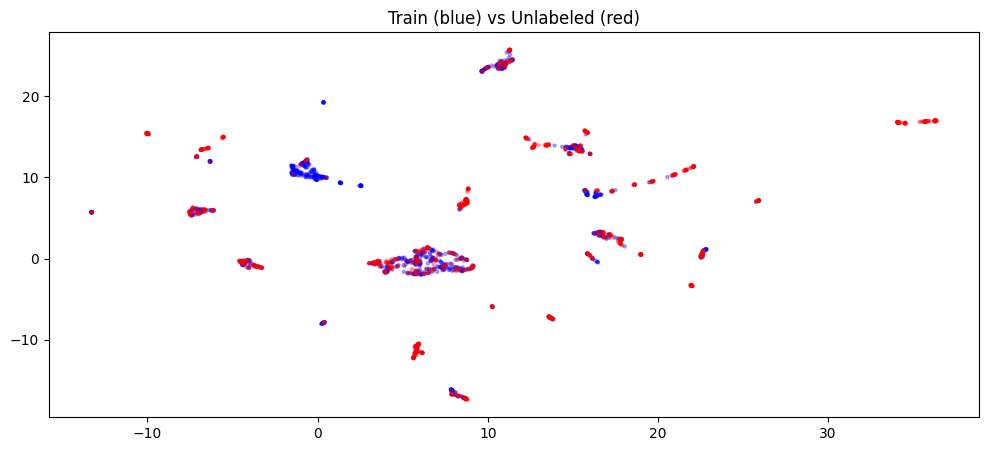

In [15]:
import pandas as pd 
import pickle
import umap
import matplotlib.pyplot as plt
import numpy as np

datatype = 'entity'
with open(f'src/classifiers/ml/features/feature_cols_{datatype}.pkl', 'rb') as f:
    feature_cols = pickle.load(f)
print(feature_cols)

df_train = pd.read_csv(f'src/classifiers/ml/features/gs_features_{datatype}.csv')
df_train = df_train[feature_cols]

# 421793 rows, features:value_diff_abs, sign_change, precision_change, length_increase, whole_number_change, old_is_prefix_of_new, new_is_prefix_of_old, same_float_value, full_cosine_similarity
df_unlabeled = pd.read_csv(f'src/classifiers/ml/features/unlabeled_features_{datatype}.csv')

# Sample unlabeled data so it's not too large
df_unlabeled_sample = df_unlabeled.sample(n=1000, random_state=42)
# Combine
X_train = df_train[feature_cols].fillna(0)
X_unlabeled = df_unlabeled_sample[feature_cols].fillna(0)

X_combined = np.vstack([X_train, X_unlabeled])
source = ['train'] * len(X_train) + ['unlabeled'] * len(X_unlabeled)

# Fit UMAP
reducer = umap.UMAP(random_state=42, n_neighbors=15, min_dist=0.1)
embedding = reducer.fit_transform(X_combined)

# Plot by source
fig, axes = plt.subplots(figsize=(12, 5))

# Plot 1: train vs unlabeled
colors = ['blue' if s == 'train' else 'red' for s in source]
axes.scatter(embedding[:, 0], embedding[:, 1], c=colors, alpha=0.3, s=5)
axes.set_title('Train (blue) vs Unlabeled (red)')

## Globecoordinate
### Distribution of features (Training vs Rest) - Latitude

In [39]:
import pandas as pd 
datatype = 'globecoordinate'
with open(f'src/classifiers/ml/features/feature_cols_{datatype}_latitude.pkl', 'rb') as f:
    feature_cols = pickle.load(f)
print(', '.join(feature_cols))

df_train_globe = pd.read_csv(f'src/classifiers/ml/features/gs_features_{datatype}_latitude.csv')
df_train_globe = df_train_globe[feature_cols]
print("Training dataset stats:")
print(df_train_globe[feature_cols].describe())

# 809012 rows, latitude_sign_change, latitude_whole_number_change, latitude_precision_change, latitude_length_increase, latitude_length_decrease, latitude_old_is_prefix_of_new, latitude_new_is_prefix_of_old, latitude_same_float_value
df_train_globe = pd.read_csv(f'src/classifiers/ml/features/unlabeled_features_{datatype}.csv')

print("Full dataset stats:")
print(df_train_globe[feature_cols].describe())

latitude_sign_change, latitude_whole_number_change, latitude_precision_change, latitude_length_increase, latitude_length_decrease, latitude_old_is_prefix_of_new, latitude_new_is_prefix_of_old, latitude_same_float_value
Training dataset stats:
       latitude_sign_change  latitude_whole_number_change  \
count           1010.000000                   1010.000000   
mean               0.070297                      0.096040   
std                0.255774                      0.294792   
min                0.000000                      0.000000   
25%                0.000000                      0.000000   
50%                0.000000                      0.000000   
75%                0.000000                      0.000000   
max                1.000000                      1.000000   

       latitude_precision_change  latitude_length_increase  \
count                1010.000000               1010.000000   
mean                    0.666337                  0.123762   
std                  

### UMAP

['latitude_sign_change', 'latitude_whole_number_change', 'latitude_precision_change', 'latitude_length_increase', 'latitude_length_decrease', 'latitude_old_is_prefix_of_new', 'latitude_new_is_prefix_of_old', 'latitude_same_float_value']


/sc/home/carolina.cortes/conda3/envs/venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Text(0.5, 1.0, 'Train (blue) vs Unlabeled (red)')

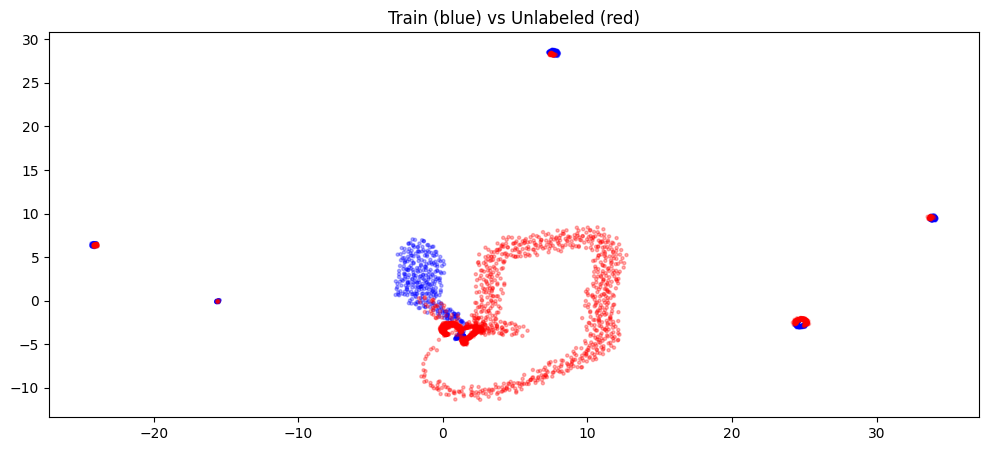

In [20]:
import pandas as pd 
import pickle
import umap
import matplotlib.pyplot as plt
import numpy as np

datatype = 'globecoordinate'
part = 'latitude'
with open(f'src/classifiers/ml/features/feature_cols_{datatype}_{part}.pkl', 'rb') as f:
    feature_cols = pickle.load(f)
print(feature_cols)

df_train = pd.read_csv(f'src/classifiers/ml/features/gs_features_{datatype}_{part}.csv')
df_train = df_train[feature_cols]

# 421793 rows, features:value_diff_abs, sign_change, precision_change, length_increase, whole_number_change, old_is_prefix_of_new, new_is_prefix_of_old, same_float_value, full_cosine_similarity
df_unlabeled = pd.read_csv(f'src/classifiers/ml/features/unlabeled_features_{datatype}.csv')

# Sample unlabeled data so it's not too large
df_unlabeled_sample = df_unlabeled.sample(n=2000, random_state=42)
# Combine
X_train = df_train[feature_cols].fillna(0)
X_unlabeled = df_unlabeled_sample[feature_cols].fillna(0)

X_combined = np.vstack([X_train, X_unlabeled])
source = ['train'] * len(X_train) + ['unlabeled'] * len(X_unlabeled)

X_combined = np.where(np.isinf(X_combined), np.nan, X_combined)
X_combined = np.nan_to_num(X_combined, nan=0.0, posinf=0.0, neginf=0.0)

# Fit UMAP
reducer = umap.UMAP(random_state=42, n_neighbors=15, min_dist=0.1)
embedding = reducer.fit_transform(X_combined)

# Plot by source
fig, axes = plt.subplots(figsize=(12, 5))

# Plot 1: train vs unlabeled
colors = ['blue' if s == 'train' else 'red' for s in source]
axes.scatter(embedding[:, 0], embedding[:, 1], c=colors, alpha=0.3, s=5)
axes.set_title('Train (blue) vs Unlabeled (red)')

### Longitude

In [9]:
import pickle
import pandas as pd 
datatype = 'globecoordinate'
part = 'longitude'
with open(f'src/classifiers/ml/features/feature_cols_{datatype}_{part}.pkl', 'rb') as f:
    feature_cols = pickle.load(f)
print(', '.join(feature_cols))

df_train_globe = pd.read_csv(f'src/classifiers/ml/features/gs_features_{datatype}_{part}.csv')
df_train_globe = df_train_globe[feature_cols]
print("Training dataset stats:")
print(df_train_globe[feature_cols].describe())

# 809012 rows, latitude_sign_change, latitude_whole_number_change, latitude_precision_change, latitude_length_increase, latitude_length_decrease, latitude_old_is_prefix_of_new, latitude_new_is_prefix_of_old, latitude_same_float_value
df_train_globe = pd.read_csv(f'src/classifiers/ml/features/unlabeled_feature_{part}.csv')

print("Full dataset stats:")
print(df_train_globe[feature_cols].describe())

longitude_sign_change, longitude_whole_number_change, longitude_precision_change, longitude_length_increase, longitude_length_decrease, longitude_old_is_prefix_of_new, longitude_new_is_prefix_of_old, longitude_same_float_value
Training dataset stats:
       longitude_sign_change  longitude_whole_number_change  \
count            1010.000000                    1010.000000   
mean                0.195050                       0.081188   
std                 0.396435                       0.273259   
min                 0.000000                       0.000000   
25%                 0.000000                       0.000000   
50%                 0.000000                       0.000000   
75%                 0.000000                       0.000000   
max                 1.000000                       1.000000   

       longitude_precision_change  longitude_length_increase  \
count                 1010.000000                1010.000000   
mean                     0.600990                   0

### UMAP

['longitude_sign_change', 'longitude_whole_number_change', 'longitude_precision_change', 'longitude_length_increase', 'longitude_length_decrease', 'longitude_old_is_prefix_of_new', 'longitude_new_is_prefix_of_old', 'longitude_same_float_value']


/sc/home/carolina.cortes/conda3/envs/venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Text(0.5, 1.0, 'Train (blue) vs Unlabeled (red)')

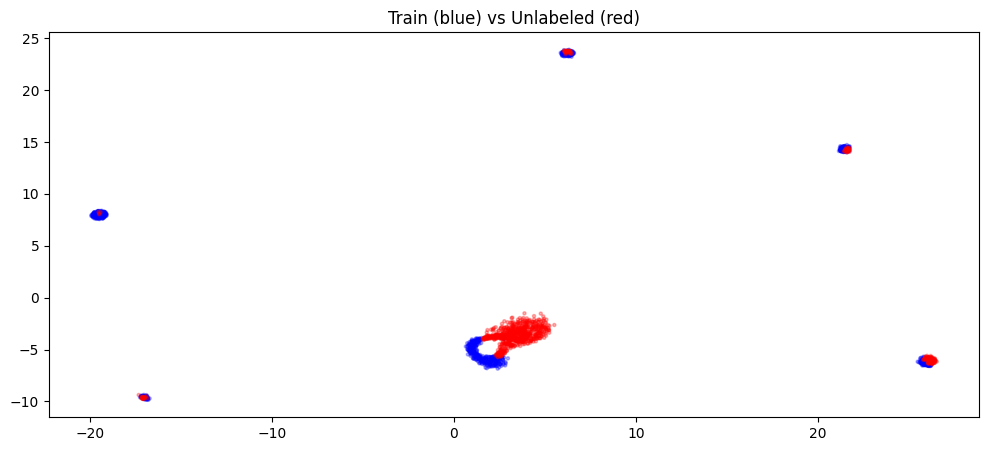

In [17]:
import pandas as pd 
import pickle
import umap
import matplotlib.pyplot as plt
import numpy as np

datatype = 'globecoordinate'
part = 'longitude'
with open(f'src/classifiers/ml/features/feature_cols_{datatype}_{part}.pkl', 'rb') as f:
    feature_cols = pickle.load(f)
print(feature_cols)

df_train = pd.read_csv(f'src/classifiers/ml/features/gs_features_{datatype}_{part}.csv')
df_train = df_train[feature_cols]

# 421793 rows, features:value_diff_abs, sign_change, precision_change, length_increase, whole_number_change, old_is_prefix_of_new, new_is_prefix_of_old, same_float_value, full_cosine_similarity
df_unlabeled = pd.read_csv(f'src/classifiers/ml/features/unlabeled_feature_{part}.csv')

# Sample unlabeled data so it's not too large
df_unlabeled_sample = df_unlabeled.sample(n=1000, random_state=42)
# Combine
X_train = df_train[feature_cols].fillna(0)
X_unlabeled = df_unlabeled_sample[feature_cols].fillna(0)

X_combined = np.vstack([X_train, X_unlabeled])
source = ['train'] * len(X_train) + ['unlabeled'] * len(X_unlabeled)

X_combined = np.where(np.isinf(X_combined), np.nan, X_combined)
X_combined = np.nan_to_num(X_combined, nan=0.0, posinf=0.0, neginf=0.0)

# Fit UMAP
reducer = umap.UMAP(random_state=42, n_neighbors=15, min_dist=0.1)
embedding = reducer.fit_transform(X_combined)

# Plot by source
fig, axes = plt.subplots(figsize=(12, 5))

# Plot 1: train vs unlabeled
colors = ['blue' if s == 'train' else 'red' for s in source]
axes.scatter(embedding[:, 0], embedding[:, 1], c=colors, alpha=0.3, s=5)
axes.set_title('Train (blue) vs Unlabeled (red)')

## Time
### Distribution of features (Training vs Rest)

In [28]:
import pandas as pd 
datatype = 'time'
with open(f'src/classifiers/ml/features/feature_cols_{datatype}.pkl', 'rb') as f:
    feature_cols = pickle.load(f)
print(feature_cols)

df_train_time = pd.read_csv(f'src/classifiers/ml/features/gs_features_{datatype}.csv')
df_train_time = df_train_time[feature_cols]
print("Training dataset stats:")
print(df_train_time[feature_cols].describe())

# 421793 rows, features:value_diff_abs, sign_change, precision_change, length_increase, whole_number_change, old_is_prefix_of_new, new_is_prefix_of_old, same_float_value, full_cosine_similarity
df_unlabeled_time = pd.read_csv(f'src/classifiers/ml/features/unlabeled_features_{datatype}.csv')

print("Full dataset stats:")
print(df_unlabeled_time[feature_cols].describe())

['date_diff_days', 'sign_change', 'change_one_to_zero', 'day_added', 'day_removed', 'month_added', 'month_removed', 'different_year', 'different_day', 'different_month', 'full_cosine_similarity']
Training dataset stats:
       date_diff_days  sign_change  change_one_to_zero    day_added  \
count    1.619000e+03  1619.000000         1619.000000  1619.000000   
mean     1.135572e+15     0.061767            0.202594     0.123533   
std      2.372926e+16     0.240805            0.402057     0.329150   
min      0.000000e+00     0.000000            0.000000     0.000000   
25%      3.100000e+01     0.000000            0.000000     0.000000   
50%      2.850000e+02     0.000000            0.000000     0.000000   
75%      8.456650e+04     0.000000            0.000000     0.000000   
max      7.157202e+17     1.000000            1.000000     1.000000   

       day_removed  month_added  month_removed  different_year  different_day  \
count  1619.000000  1619.000000    1619.000000     1619.000

['date_diff_days', 'sign_change', 'change_one_to_zero', 'day_added', 'day_removed', 'month_added', 'month_removed', 'different_year', 'different_day', 'different_month']


/sc/home/carolina.cortes/conda3/envs/venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Text(0.5, 1.0, 'Train (blue) vs Unlabeled (red)')

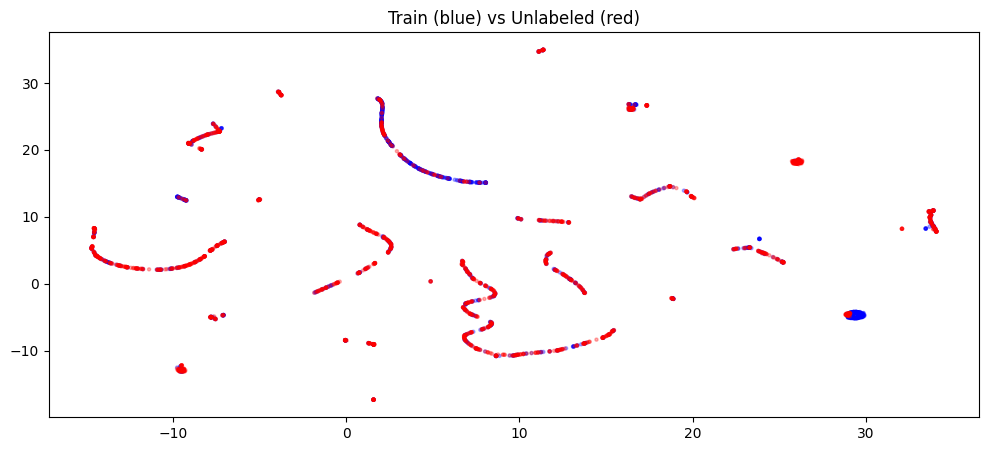

In [18]:
import pandas as pd 
import pickle
import umap
import matplotlib.pyplot as plt
import numpy as np

# quantity
with open(f'src/classifiers/ml/features/feature_cols_time.pkl', 'rb') as f:
    feature_cols = pickle.load(f)
print(feature_cols)

df_train_time = pd.read_csv('src/classifiers/ml/features/gs_features_time.csv')
df_train_time = df_train_time[feature_cols]

# 421793 rows, features:value_diff_abs, sign_change, precision_change, length_increase, whole_number_change, old_is_prefix_of_new, new_is_prefix_of_old, same_float_value, full_cosine_similarity
df_unlabeled_time = pd.read_csv('src/classifiers/ml/features/unlabeled_features_time.csv')

# Sample unlabeled data so it's not too large
df_unlabeled_sample = df_unlabeled_time.sample(n=2000, random_state=42)
# Combine
X_train = df_train_time[feature_cols].fillna(0)
X_unlabeled = df_unlabeled_sample[feature_cols].fillna(0)

X_combined = np.vstack([X_train, X_unlabeled])
source = ['train'] * len(X_train) + ['unlabeled'] * len(X_unlabeled)

X_combined = np.where(np.isinf(X_combined), np.nan, X_combined)
X_combined = np.nan_to_num(X_combined, nan=0.0, posinf=0.0, neginf=0.0)

# Fit UMAP
reducer = umap.UMAP(random_state=42, n_neighbors=15, min_dist=0.1)
embedding = reducer.fit_transform(X_combined)

# Plot by source
fig, axes = plt.subplots(figsize=(12, 5))

# Plot 1: train vs unlabeled
colors = ['blue' if s == 'train' else 'red' for s in source]
axes.scatter(embedding[:, 0], embedding[:, 1], c=colors, alpha=0.3, s=5)
axes.set_title('Train (blue) vs Unlabeled (red)')

## Quantity
### Distribution of features (Training vs Rest)

In [ ]:
import pandas as pd 
datatype = 'quantity'
with open(f'src/classifiers/ml/features/feature_cols_{datatype}.pkl', 'rb') as f:
    feature_cols = pickle.load(f)
print(feature_cols)

df_train_quantity = pd.read_csv(f'src/classifiers/ml/features/gs_features_{datatype}.csv')
df_train_quantity = df_train_quantity[feature_cols]
print("Training dataset stats:")
print(df_train_quantity[feature_cols].describe())

# 421793 rows, features:value_diff_abs, sign_change, precision_change, length_increase, whole_number_change, old_is_prefix_of_new, new_is_prefix_of_old, same_float_value, full_cosine_similarity
df_unlabeled_quantity = pd.read_csv(f'src/classifiers/ml/features/unlabeled_features_{datatype}.csv')
df_unlabeled_quantity['value_diff_abs'] = df_unlabeled_quantity['value_diff_abs'].clip(-1e15, 1e15)

print("Full dataset stats:")
print(df_unlabeled_quantity[feature_cols].describe())

Training dataset stats:
       value_diff_abs  sign_change  precision_change  length_increase  \
count    9.270000e+02   927.000000        927.000000       927.000000   
mean    1.550030e+101     0.162891          0.476807         0.236246   
std     3.334534e+102     0.369466          0.499731         0.425004   
min      0.000000e+00     0.000000          0.000000         0.000000   
25%      0.000000e+00     0.000000          0.000000         0.000000   
50%      4.200000e-01     0.000000          0.000000         0.000000   
75%      1.888000e+01     0.000000          1.000000         0.000000   
max     7.182818e+103     1.000000          1.000000         1.000000   

       whole_number_change  old_is_prefix_of_new  new_is_prefix_of_old  \
count           927.000000            927.000000            927.000000   
mean              0.264293              0.236246              0.278317   
std               0.441194              0.425004              0.448412   
min               0.00

### UMAP of features (Training vs Rest)

/sc/home/carolina.cortes/conda3/envs/venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Text(0.5, 1.0, 'Train (blue) vs Unlabeled (red)')

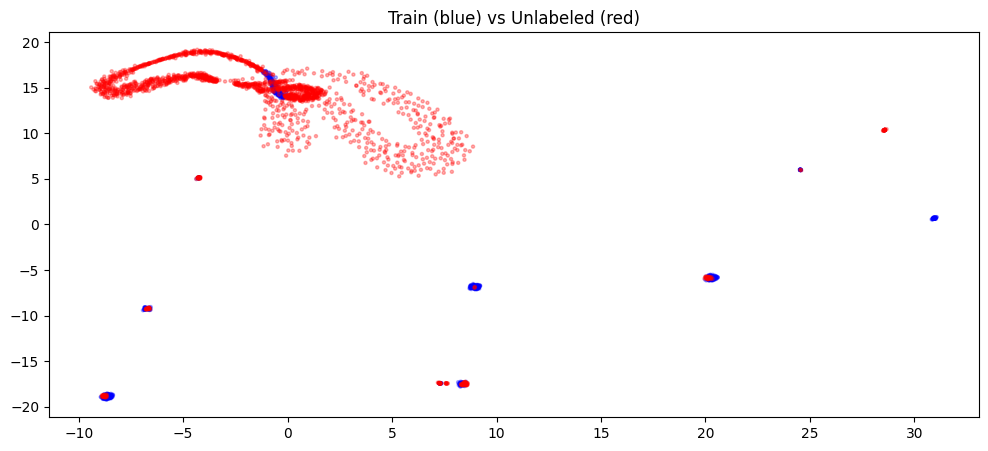

In [19]:
import pandas as pd 
import pickle
import umap
import matplotlib.pyplot as plt
import numpy as np

# quantity
with open(f'src/classifiers/ml/features/feature_cols_quantity.pkl', 'rb') as f:
    feature_cols = pickle.load(f)

df_train_quantity = pd.read_csv('src/classifiers/ml/features/gs_features_quantity.csv')
df_train_quantity = df_train_quantity[feature_cols]

# 421793 rows, features:value_diff_abs, sign_change, precision_change, length_increase, whole_number_change, old_is_prefix_of_new, new_is_prefix_of_old, same_float_value, full_cosine_similarity
df_unlabeled_quantity = pd.read_csv('src/classifiers/ml/features/unlabeled_features_quantity.csv')

# Sample unlabeled data so it's not too large
df_unlabeled_sample = df_unlabeled_quantity.sample(n=2000, random_state=42)
# Combine
X_train = df_train_quantity[feature_cols].fillna(0)
X_unlabeled = df_unlabeled_sample[feature_cols].fillna(0)

X_combined = np.vstack([X_train, X_unlabeled])
source = ['train'] * len(X_train) + ['unlabeled'] * len(X_unlabeled)

# df_combined = pd.DataFrame(X_combined, columns=feature_cols_no_diff)
# df_combined['value_diff_abs'] = df_combined['value_diff_abs'].clip(-1e15, 1e15)
# df_combined['value_diff_abs'] = np.log1p(df_combined['value_diff_abs'].abs())
# X_combined = df_combined.values

X_combined = np.where(np.isinf(X_combined), np.nan, X_combined)
X_combined = np.nan_to_num(X_combined, nan=0.0, posinf=0.0, neginf=0.0)

# Fit UMAP
reducer = umap.UMAP(random_state=42, n_neighbors=15, min_dist=0.1)
embedding = reducer.fit_transform(X_combined)

# Plot by source
fig, axes = plt.subplots(figsize=(12, 5))

# Plot 1: train vs unlabeled
colors = ['blue' if s == 'train' else 'red' for s in source]
axes.scatter(embedding[:, 0], embedding[:, 1], c=colors, alpha=0.3, s=5)
axes.set_title('Train (blue) vs Unlabeled (red)')